Introduction to Deep Learning
===

___

Author: <u>*Virtsudo*</u>

Date **May 2026**

## 0. Utils preparation

### 0.1 Imports and Plots

In [33]:
# imports
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.nn import CrossEntropyLoss
from dataclasses import dataclass
import matplotlib.pyplot as plt
from torch import optim
from typing import Any
import seaborn as sns
from torch import nn
import pandas as pd
import numpy as np
import unicodedata
import torch
import time
import re

In [34]:
# file naming wrapper
def name_wrapper(text: str, fallback: str = "file", max_len: int = 255) -> str:
    cleaned = "".join(ch for ch in re.sub(r"\s+", "_", unicodedata.normalize("NFKC", text.lower()).strip()) if ch.isalnum() or ch in {"_", "-", "."}).rstrip(" .")
    if not cleaned: cleaned = fallback
    return cleaned[:max_len]

In [35]:
# plots
def plot_train_val_curve(title: str, train_losses: list, val_losses: list):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss of {title}")
    plt.legend()
    plt.savefig(f"../report/img/train_val_curve_{name_wrapper(title)}.png")
    plt.show()

def plot_confusion_matrix(title: str, y_true, y_pred, class_names: list[str]):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix of {title}")
    plt.savefig(f"../report/img/confusion_matrix_{name_wrapper(title)}.png")
    plt.show()

def plot_box(title: str, x):
    plt.figure(figsize=(16, 6))
    sns.boxplot(data=x, orient="h", showfliers=True)
    plt.title(f"Boxplot of features for {title}")
    plt.xlabel("Feature value")
    plt.tight_layout()
    plt.savefig(f"../report/img/boxplot_{name_wrapper(title)}.png")
    plt.show()

def plot_bar(title: str, items1: dict[str, int], items2: dict[str, int], item_names: tuple[str, str], y: str = None):
    items: list[str] = sorted(set(items1) | set(items2))
    counts1 = np.array([int(items1.get(i, 0)) for i in items], dtype=int)
    counts2  = np.array([int(items2.get(i, 0))  for i in items], dtype=int)
    x = np.arange(len(items))
    fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(items)), 5))
    ax.bar(x - 0.2, counts1, width=0.4, label=item_names[0])
    ax.bar(x + 0.2, counts2,  width=0.4, label=item_names[1])

    ax.set_title(title)
    for i, v in enumerate(counts1):
        ax.text(i - 0.2, v + 1, f"{v}", ha="center", va="bottom", fontsize=8)
    for i, v in enumerate(counts2):
        ax.text(i + 0.2, v + 1, f"{v}", ha="center", va="bottom", fontsize=8)
    if y is not None: ax.set_ylabel(y)
    ax.set_xticks(x)
    ax.set_xticklabels(items, rotation=45, ha="right")
    ax.legend()
    fig.tight_layout()
    plt.savefig(f"../report/img/bar_{name_wrapper(title)}.png")
    plt.show()

### 0.2 Reusable components

In [36]:
# define preprocessor function
class Preprocessor:
    """
    This preprocessor class contains fundamental preprocessing tools:
        init -> define essential props
        preprocess -> preprocess dataset
        data cleaning -> remove duplicated, infinite and nan values
        get input dim -> returns number of features
        get replaced ports -> used specifically for task#3
        get unique labels -> returns unique labels
        get num samples -> returns number of samples
    """

    def __init__(self, df_path: str, excl_feature: str = None):
        # set random seed for reproducibility
        np.random.seed(42)
        torch.manual_seed(42)
        if torch.cuda.is_available(): torch.cuda.manual_seed(42)

        # define scaler, encoder
        self.__scaler = RobustScaler()
        self.__label_encoder = LabelEncoder()

        # load main dataframe
        self.__df = pd.read_csv(df_path)
        if excl_feature is not None:
            self.__df.drop(columns=[excl_feature], errors="ignore", inplace=True)
        print(self.__df.head())

        self.is_cleaned = False

    def preprocess(self):
        # split the dataset
        self.__X = self.__df.drop(columns=['Label'])
        self.__y = self.__df['Label']

        self.X_train, X_tmp, self.y_train, y_tmp = train_test_split(self.__X, self.__y, test_size=0.4, random_state=42,
                                                                    stratify=self.__y)
        self.X_val, self.X_test, self.y_val, self.y_test = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                                                            random_state=42, stratify=y_tmp)

        # for task#3
        self.X_test_p = self.X_test.copy()
        self.y_test_p = self.y_test.copy()

        # plot boxplot of features
        plot_box("Cleaned training set", self.X_train)

        # normalize features and encode categorical labels
        self.X_train = self.__scaler.fit_transform(self.X_train)
        self.X_val = self.__scaler.transform(self.X_val)
        self.X_test = self.__scaler.transform(self.X_test)

        self.y_train = self.__label_encoder.fit_transform(self.y_train)
        self.y_val = self.__label_encoder.transform(self.y_val)
        self.y_test = self.__label_encoder.transform(self.y_test)

        # conver to tensors
        self.X_train_tensor = torch.tensor(self.X_train, dtype=torch.float)
        self.X_val_tensor = torch.tensor(self.X_val, dtype=torch.float)
        self.X_test_tensor = torch.tensor(self.X_test, dtype=torch.float)

        self.y_train_tensor = torch.tensor(self.y_train, dtype=torch.long)
        self.y_val_tensor = torch.tensor(self.y_val, dtype=torch.long)
        self.y_test_tensor = torch.tensor(self.y_test, dtype=torch.long)

        # convert to dataset
        self.train_dataset = TensorDataset(self.X_train_tensor, self.y_train_tensor)
        self.val_dataset = TensorDataset(self.X_val_tensor, self.y_val_tensor)
        self.test_dataset = TensorDataset(self.X_test_tensor, self.y_test_tensor)

        self.__unique_labels = list(self.__label_encoder.classes_)

    # define data cleaning function
    def data_cleaning(self):
        print(f"Number of rows (before data cleaning): {self.__df.shape[0]}")

        # replacing +-inf to NaN
        self.__df.replace([-np.inf, np.inf], np.nan, inplace=True)

        # removing missing values
        self.__df.dropna(inplace=True)

        # removing duplicates
        self.__df.drop_duplicates(inplace=True)

        print(f"Number of rows (after data cleaning): {self.__df.shape[0]}")

        self.is_cleaned = True

    def convert_to_loader(self, batch_size: int, test: bool = True, port: bool = False):
        lds = {
            "train_loader": DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True),
            "val_loader": DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
        }
        if test: lds["test_loader"] = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False)
        if port: lds["test_p_loader"] = DataLoader(self.get_replaced_port(), batch_size=batch_size, shuffle=False)
        return lds

    def get_replaced_port(self):
        mask = (self.y_test_p == "Brute Force") & (self.X_test_p["Destination Port"] == 80)
        self.X_test_p.loc[mask, "Destination Port"] = 8080
        self.X_test_p = self.__scaler.transform(self.X_test_p)
        self.X_test_p_tensor = torch.tensor(self.X_test_p, dtype=torch.float)
        self.test_p_dataset = TensorDataset(self.X_test_p_tensor, self.y_test_tensor)
        return self.test_p_dataset

    def get_label_count(self):
        return self.__y.value_counts().reindex(self.__unique_labels, fill_value=0)

    def get_input_dim(self):
        return self.X_train.shape[1]  # return # of features

    def get_unique_labels(self):
        return self.__unique_labels  # return unique labels

    def get_num_samples(self):
        return self.__df.shape[0]  # num of samples

In [37]:
# defin arguments data class
@dataclass
class Arguments:
    lr: float
    batch_size: int
    num_epochs: int
    criterion: Any
    input_dim: int
    hidden_dims: tuple[int, ...]
    output_dim: int
    min_delta: float = None
    patience: int = None

In [38]:
# define shallow nn model
class ShallowNN(nn.Module):
    """
    Args:
        input_dim: feature size of the neural network
        hidden_dim: hidden layer size
        output_dim: label size of the neural network
        activation: if True - activation function set ReLU
    """
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, activation: bool = False):
        super(ShallowNN, self).__init__()

        layers = list()

        layers.append(nn.Linear(input_dim, hidden_dim))
        if activation: layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [39]:
# define deep nn model
class DeepFFNN(nn.Module):
    """
    Args:
        input_dim: feature size of the neural network
        hidden_dims: hidden layer size
        output_dim: label size of the neural network
        dropout: dropout rate
        norm: Normalization function
    """
    def __init__(self, input_dim: int, hidden_dims: tuple[int, ...], output_dim: int, dropout: float = 0.0):
        super(DeepFFNN, self).__init__()

        layers = list()
        h = input_dim

        for ih in hidden_dims:
            layers.append(nn.Linear(h, ih))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout))
            h = ih

        layers.append(nn.Linear(h, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [40]:
# define get_class_report function
def get_class_report(model, dataloader, device, target_names):
    model.eval()  # Set the model to evaluation mode
    y_true, y_pred = list(), list()

    with torch.no_grad():  # Disable gradient computation for efficiency
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)  # Move batch to GPU
            logits = model(x)
            pred = logits.argmax(dim=1)
            y_true.append(y.detach().cpu().numpy())
            y_pred.append(pred.detach().cpu().numpy())

    y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)
    return classification_report(y_true, y_pred, target_names=target_names, zero_division=0.0)

In [41]:
# Define training loop
def training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, num_epochs, model_name, unique_labels, min_delta = None, patience = None):
    """
        Train the model for a specified number of epochs and track the training and validation losses.

        Args:
            model: The neural network model to be trained.
            train_loader: DataLoader for the training dataset.
            val_loader: DataLoader for the validation dataset.
            train_dataset: The entire training dataset.
            val_dataset: The entire validation dataset.
            device: Device to run the model on (CPU or GPU).
            optimizer: The optimization algorithm to use for updating model parameters.
            criterion: The loss function to use for computing the loss.
            model_name: The name of the model to be trained.
            min_delta: difference value for early stooping
            patience: Number of epochs without improvement

        Returns:
            Best validation loss
        """

    # Record the start time
    start_time = time.time()

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    trigger_times = 0
    best_model_state = None

    # Training loop
    for epoch in range(num_epochs):  # Train for epochs
        train_loss = 0
        val_loss = 0
        model.train()  # Set model to training mode
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)  # Move batch to GPU
            optimizer.zero_grad()  # Clear previous gradients
            outputs = model(batch_X)  # Forward pass
            loss = criterion(outputs, batch_y)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update model parameters
            train_loss += loss.item() * batch_X.size(0)
        train_loss /= len(train_dataset)
        train_losses.append(train_loss)  # Store training loss

        # Compute Validation loss during training
        model.eval()  # Set model to evaluation mode
        with torch.no_grad():  # Disable gradient computation for validation
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)  # Move batch to GPU
                val_outputs = model(batch_X)  # Forward pass
                loss = criterion(val_outputs, batch_y)  # Compute validation loss
                val_loss += loss.item() * batch_X.size(0)
            val_loss /= len(val_dataset)
            val_losses.append(val_loss)  # Store validation loss
        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

        # early stopping
        if min_delta is not None and patience is not None:
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                trigger_times = 0
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    print(f"Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.6f})")
                    break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Record the end time
    end_time = time.time()
    # Calculate the elapsed time
    elapsed_time = end_time - start_time
    print(f'The function took {elapsed_time:.4f} seconds to execute.')

    print(f"\n\nClass Report {model_name}:\n{get_class_report(model, val_loader, device, unique_labels)}")
    plot_train_val_curve(f"{model_name}", train_losses, val_losses)

    return best_val_loss if min_delta is not None else val_loss

In [42]:
# Define testing model
def testing_model(model, dataloader, device, model_name, unique_labels):
    """
    Evaluate the model on a given dataloader and compute accuracy.

    Args:
        model: The trained model.
        dataloader: DataLoader for the dataset.
        device: Device to run the model on (CPU or GPU)
        model_name: The name of the model to be tested

    Returns:
        float: Accuracy of the model on the test dataset.
    """
    # Record the start time
    start_time = time.time()

    model.eval()  # Set the model to evaluation mode
    all_labels, all_predictions = list(), list()

    with torch.no_grad():  # Disable gradient computation for efficiency
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move batch to GPU
            outputs = model(inputs)
            predicted = outputs.argmax(dim=1)
            all_labels.append(labels.detach().cpu().numpy())
            all_predictions.append(predicted.detach().cpu().numpy())

    all_labels, all_predictions = np.concatenate(all_labels), np.concatenate(all_predictions)
    accuracy = accuracy_score(all_labels, all_predictions) * 100

    # Record the end time
    end_time = time.time()
    # Calculate the elapsed time
    elapsed_time = end_time - start_time
    print(f'The function took {elapsed_time:.4f} seconds to execute.')

    print(f"\n\nClass Report {model_name}:\n{classification_report(all_labels, all_predictions, zero_division=0.0, target_names=unique_labels)}")
    plot_confusion_matrix(f"{model_name}", all_labels, all_predictions, class_names=unique_labels)

    return accuracy

## 1. Data Preprocessing

In [43]:
# define preprocessor object
prep = Preprocessor("../data/dataset_lab_1.csv")

   Flow Duration  Flow IAT Mean  Fwd PSH Flags  Bwd Packet Length Mean  \
0         303376   30337.600000              0                   749.4   
1            117     117.000000              0                     0.0   
2            142     142.000000              0                     0.0   
3            191      63.666668              0                    52.0   
4              4       4.000000              0                     0.0   

   Bwd Packet Length Max  Flow Bytes/s  Down/Up Ratio  SYN Flag Count  \
0                   1448     12743.263              0               0   
1                      0         0.000              1               0   
2                      0     84507.040              0               0   
3                     52    921465.940              1               0   
4                      0   3000000.000              0               0   

   Fwd Packet Length Mean  Fwd IAT Std  Packet Length Mean  \
0               19.833334     98776.15           322.1

In [44]:
# data cleaning
prep.data_cleaning()

Number of rows (before data cleaning): 31507
Number of rows (after data cleaning): 29386


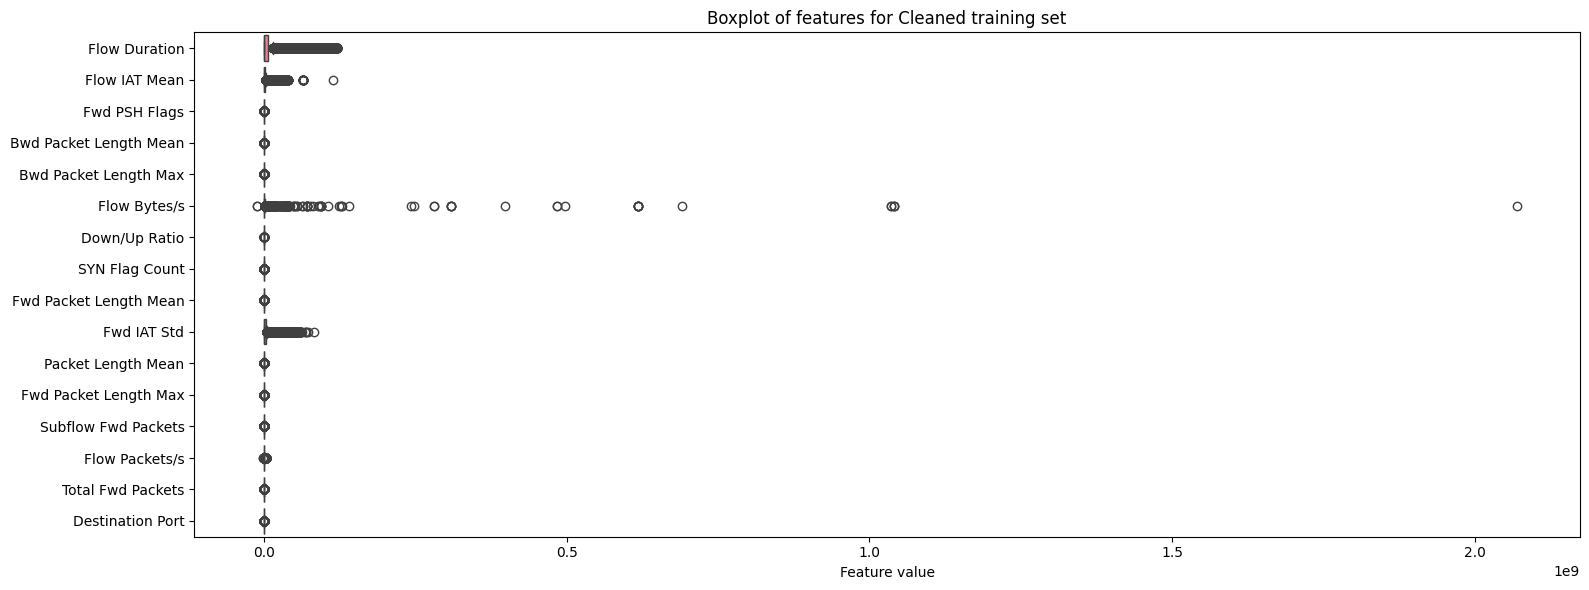

In [45]:
# preprocessing
prep.preprocess()

Data input (features) normalized with RobustScaler, because the boxplot shows outliers across features. RobustScaler is less sensitive to extreme values  comparing to StandardScaler. Labels were encoded with LabelEncoder to convert class names into numeric classes.

In [46]:
# extract unique labels on encoder order
unique_labels = prep.get_unique_labels()
print(f"Unique Labels: {unique_labels}")

Unique Labels: ['Benign', 'Brute Force', 'DoS Hulk', 'PortScan']


## 2. Shallow Neural Network

### 2.1 Shallow Learning Model

In [47]:
# hyperparameters
args = Arguments(
    lr=0.0005,
    batch_size=64,
    num_epochs=100,
    criterion=CrossEntropyLoss(),
    input_dim=prep.get_input_dim(),
    hidden_dims=(),
    output_dim=len(unique_labels),
    min_delta=1e-3,
    patience=5
)
models: dict[str, Any] = {f"hidden-{k}": { **vars(args), f"hidden_dim": k} for k in [32, 64, 128]}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {str(device).upper()}")

Device: CUDA


In [48]:
# create dataloader
lds = prep.convert_to_loader(models['hidden-32']['batch_size'], port=True)
train_loader = lds["train_loader"]
val_loader = lds["val_loader"]
test_loader = lds["test_loader"]
test_p_loader = lds["test_p_loader"]

Epoch 20/100, Train Loss: 0.3045, Val Loss: 0.2988
Early stopping at epoch 24 (best val loss: 0.296084)
The function took 6.5217 seconds to execute.


Class Report Model with Hidden=32:
              precision    recall  f1-score   support

      Benign       0.92      0.95      0.94      3848
 Brute Force       0.87      0.58      0.70       286
    DoS Hulk       0.98      0.88      0.92       773
    PortScan       0.83      0.89      0.86       970

    accuracy                           0.91      5877
   macro avg       0.90      0.82      0.85      5877
weighted avg       0.91      0.91      0.91      5877



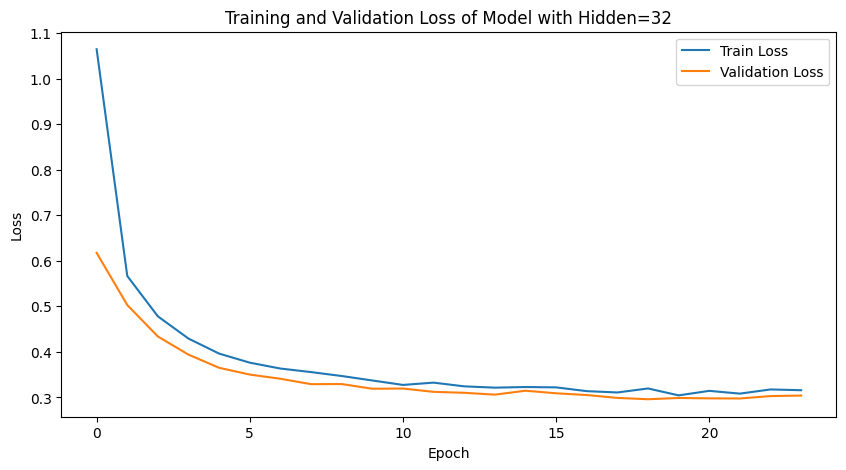

Epoch 20/100, Train Loss: 0.3101, Val Loss: 0.2957
Early stopping at epoch 33 (best val loss: 0.286151)
The function took 8.9708 seconds to execute.


Class Report Model with Hidden=64:
              precision    recall  f1-score   support

      Benign       0.89      0.96      0.92      3848
 Brute Force       0.00      0.00      0.00       286
    DoS Hulk       0.99      0.88      0.93       773
    PortScan       0.84      0.89      0.86       970

    accuracy                           0.89      5877
   macro avg       0.68      0.68      0.68      5877
weighted avg       0.85      0.89      0.87      5877



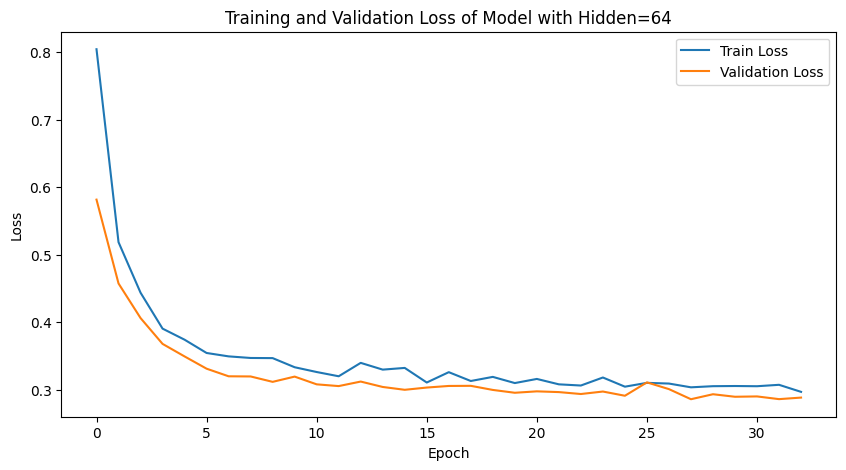

Early stopping at epoch 16 (best val loss: 0.301152)
The function took 4.4115 seconds to execute.


Class Report Model with Hidden=128:
              precision    recall  f1-score   support

      Benign       0.89      0.95      0.92      3848
 Brute Force       0.00      0.00      0.00       286
    DoS Hulk       0.98      0.88      0.93       773
    PortScan       0.83      0.88      0.86       970

    accuracy                           0.89      5877
   macro avg       0.67      0.68      0.68      5877
weighted avg       0.85      0.89      0.86      5877



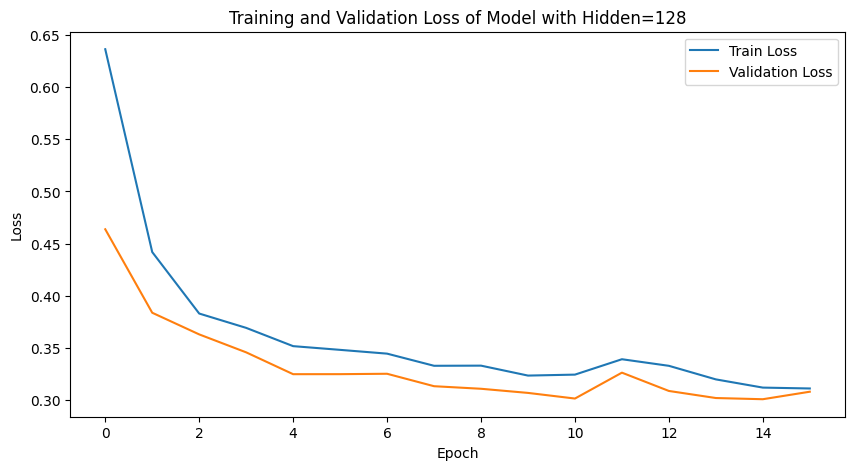

In [49]:
# define models, train
for k in models.keys():
    models[k]['model'] = ShallowNN(models[k]['input_dim'], models[k]['hidden_dim'], models[k]['output_dim']).to(device)
    models[k]['optimizer'] = optim.AdamW(models[k]['model'].parameters(), lr=models[k]['lr'])
    models[k]['best_val_loss'] = training_loop(models[k]['model'], train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, models[k]['optimizer'], models[k]['criterion'], models[k]['num_epochs'], f"Model with Hidden={k.replace('hidden-', '')}", unique_labels, args.min_delta, args.patience)

The loss curves show a typical learning evolution: both training and validation losses decrease rapidly in the first epochs and then flatten, indicating slower incremental improvement. The validation curve follows the same overall trend as the training curve, with only minor oscillations. Since both curves stabilize without divergence and without a growing train–validation gap, the models can be considered converged.

In [50]:
# extract best model
best_idx = min(models, key=lambda x: models[x]['best_val_loss'])

model = models[best_idx]['model']
optimizer = models[best_idx]['optimizer']
best_hidden_dim = int(best_idx.replace('hidden-', ''))

We collected the best validation loss from each model training, and we have chosen the model, which has the best minimum vaildation loss over all models.

The validation performance is uneven across classes.
For Hidden=32, performance is generally good on frequent classes: Benign (F1 ≈ 0.94), DoS Hulk (F1 ≈ 0.92), and PortScan (F1 ≈ 0.86), with overall accuracy ≈ 0.91 and macro-F1 ≈ 0.85.
However, the rare class Brute Force is harder (F1 ≈ 0.70, recall ≈ 0.58).
For Hidden=64 and Hidden=128, performance on Brute Force collapses (precision/recall/F1 = 0.00), which drops macro-F1 to about 0.68 despite similar overall accuracy (~0.89).
Therefore, the performance is good for majority classes but poor for the minority class in two models. This is mainly due to class imbalance and model bias toward dominant classes, so accuracy alone is misleading; macro-F1 and per-class metrics are more informative.

The function took 0.0396 seconds to execute.


Class Report Model with Hidden=64:
              precision    recall  f1-score   support

      Benign       0.89      0.96      0.92      3849
 Brute Force       0.00      0.00      0.00       285
    DoS Hulk       0.99      0.86      0.92       774
    PortScan       0.84      0.89      0.86       970

    accuracy                           0.89      5878
   macro avg       0.68      0.68      0.68      5878
weighted avg       0.85      0.89      0.87      5878



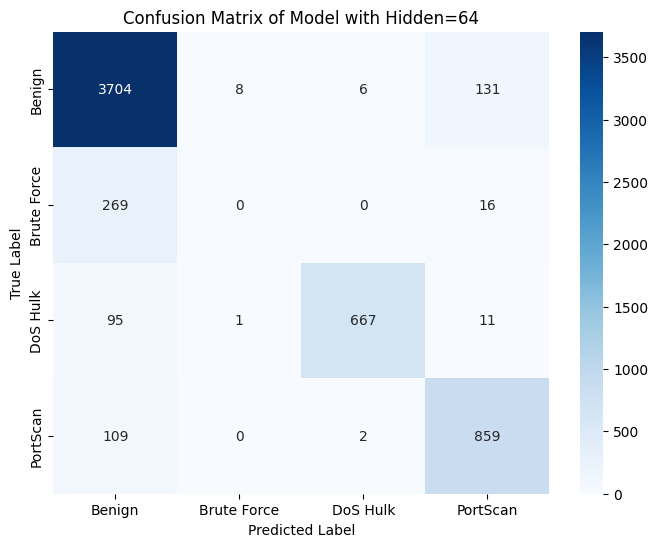

In [51]:
# test best model
acc_best_h = testing_model(model, test_loader, device, f"Model with Hidden={best_idx.replace('hidden-', '')}", unique_labels)

The performance is broadly similar between validation and test for the selected model (Hidden=64).
Validation accuracy is about 0.89 (macro-F1 about 0.68), and test accuracy is also about 0.89 (macro-F1 about 0.68).
Class-wise behavior is consistent: Benign/DoS Hulk/PortScan are predicted reasonably well, while Brute Force remains unrecognized (precision/recall/F1 ≈ 0 on both validation and test).
Therefore, the model does generalize in the sense that test behavior matches validation behavior, but it generalizes to a biased decision pattern that still fails on the minority class.

### 2.2 Activation Function

Epoch 20/100, Train Loss: 0.1090, Val Loss: 0.1149
Epoch 40/100, Train Loss: 0.0709, Val Loss: 0.0790
Early stopping at epoch 54 (best val loss: 0.070742)
The function took 16.3430 seconds to execute.


Class Report Model with activation function=ReLU:
              precision    recall  f1-score   support

      Benign       0.99      0.97      0.98      3848
 Brute Force       0.78      0.98      0.87       286
    DoS Hulk       0.98      0.98      0.98       773
    PortScan       0.99      0.99      0.99       970

    accuracy                           0.98      5877
   macro avg       0.93      0.98      0.95      5877
weighted avg       0.98      0.98      0.98      5877



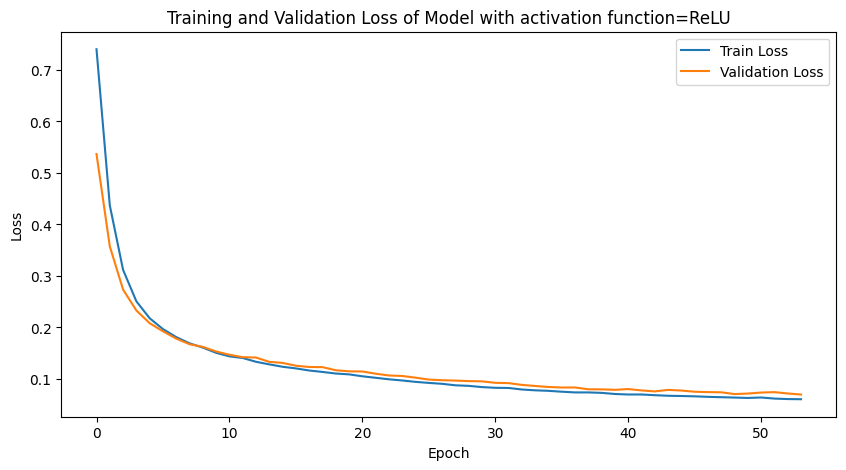

In [52]:
# model with activation function
model = ShallowNN(input_dim=args.input_dim, hidden_dim=best_hidden_dim, output_dim=args.output_dim, activation=True).to(device)
optimizer = optim.AdamW(model.parameters(), lr=args.lr)
best_val_loss = training_loop(model, train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, optimizer, args.criterion, args.num_epochs, 'Model with activation function=ReLU', unique_labels, args.min_delta, args.patience)

With ReLU, performance is very strong for PortScan, DoS Hulk, and Benign (F1 around 0.98-0.99).
It also improves the minority Brute Force class substantially, reaching recall about 0.98 and F1 about 0.87.
So the model performs best on PortScan/DoS Hulk/Benign, while Brute Force remains the hardest class, though clearly improved.

It is not correct to compare on the test set at this point, because we are still in model-selection/tuning (changing activation function). The test set must remain unseen and be used only once for final evaluation after all design choices are fixed. Comparing on test during tuning would leak information and bias the final estimate of generalization.

### 2.3 The impact of Specific Features

Assuming that all Brute Force attacks always come from destination port 80 is a dataset-specific artifact, not a robust real-world rule. Attackers can use different ports (e.g., 8080, 443, custom ports), so relying on a single port creates a spurious shortcut. This can lead the model to learn a wrong inductive bias and reduce generalization when traffic conditions change.

The function took 0.0419 seconds to execute.


Class Report Model with Baseline:
              precision    recall  f1-score   support

      Benign       0.99      0.97      0.98      3849
 Brute Force       0.79      1.00      0.88       285
    DoS Hulk       0.97      0.97      0.97       774
    PortScan       0.98      0.99      0.98       970

    accuracy                           0.97      5878
   macro avg       0.93      0.98      0.95      5878
weighted avg       0.98      0.97      0.98      5878



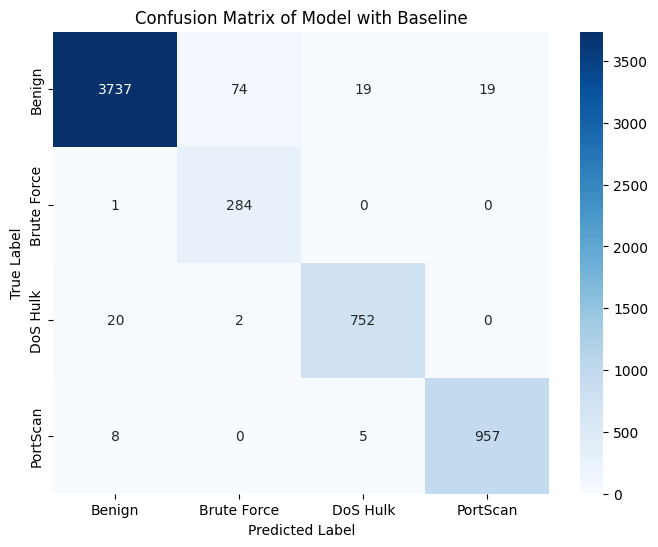

The function took 0.0399 seconds to execute.


Class Report Model with Destination Port changed 80 to 8080:
              precision    recall  f1-score   support

      Benign       0.92      0.97      0.95      3849
 Brute Force       0.00      0.00      0.00       285
    DoS Hulk       0.97      0.97      0.97       774
    PortScan       0.98      0.99      0.98       970

    accuracy                           0.93      5878
   macro avg       0.72      0.73      0.73      5878
weighted avg       0.89      0.93      0.91      5878



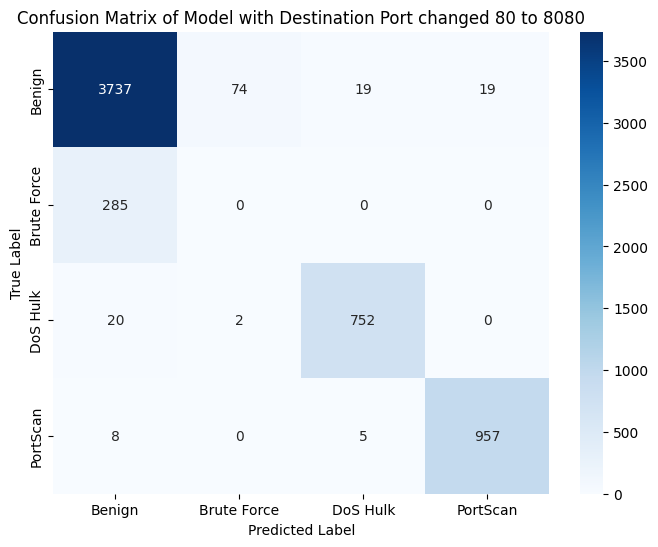

In [53]:
# X_test_p is already port replaced, we will use it
acc_base = testing_model(model, test_loader, device, "Model with Baseline", unique_labels)
acc_port = testing_model(model, test_p_loader, device, "Model with Destination Port changed 80 to 8080", unique_labels)

The performance changes significantly after replacing Brute Force destination port from 80 to 8080.
In the baseline test, Brute Force is detected well (precision ≈ 0.79, recall = 1.00, F1 ≈ 0.88), with overall accuracy ≈ 0.97 and macro-F1 ≈ 0.95.
After the port change, Brute Force collapses (precision/recall/F1 = 0.00), while other classes remain similar; overall accuracy drops to ≈ 0.93 and macro-F1 to ≈ 0.73.
This happens because the model learned a spurious shortcut tied to destination port 80 for Brute Force. When that correlation is removed, it fails to recognize the class, revealing poor robustness to feature-distribution shift.

In [54]:
# get label distribution before removing port feature
label_dist_pre = prep.get_label_count()

In [55]:
# define preprocessor object with removed port feature
prep = Preprocessor("../data/dataset_lab_1.csv", excl_feature="Destination Port")

   Flow Duration  Flow IAT Mean  Fwd PSH Flags  Bwd Packet Length Mean  \
0         303376   30337.600000              0                   749.4   
1            117     117.000000              0                     0.0   
2            142     142.000000              0                     0.0   
3            191      63.666668              0                    52.0   
4              4       4.000000              0                     0.0   

   Bwd Packet Length Max  Flow Bytes/s  Down/Up Ratio  SYN Flag Count  \
0                   1448     12743.263              0               0   
1                      0         0.000              1               0   
2                      0     84507.040              0               0   
3                     52    921465.940              1               0   
4                      0   3000000.000              0               0   

   Fwd Packet Length Mean  Fwd IAT Std  Packet Length Mean  \
0               19.833334     98776.15           322.1

In [56]:
# data cleaning
prep.data_cleaning()

Number of rows (before data cleaning): 31507
Number of rows (after data cleaning): 22469


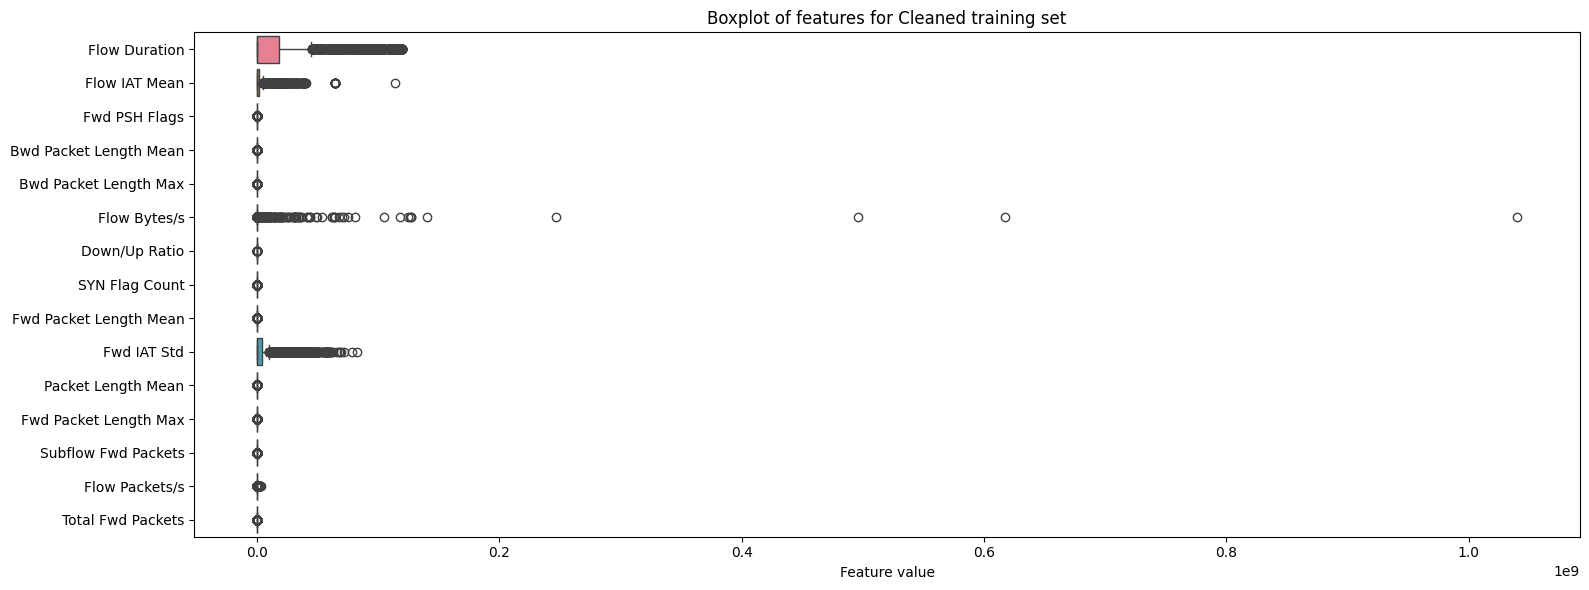

In [57]:
# preprocess again for new version
prep.preprocess()

In [58]:
# get label distribution after removing port feature
label_dist_post = prep.get_label_count()

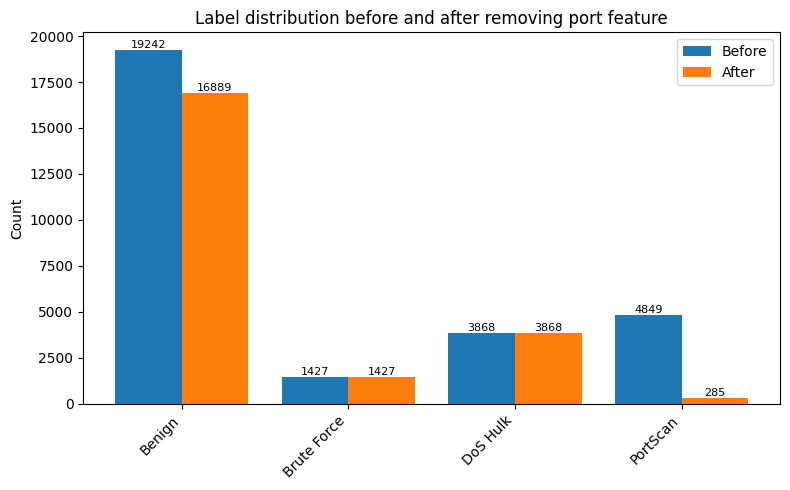

In [59]:
# plot label distribution before and after removing port feature
plot_bar("Label distribution before and after removing port feature", label_dist_pre.to_dict(), label_dist_post.to_dict(), ("Before", "After"), y="Count")

From above bar, we can see that PortScan samples dropped from 4849 to 285, difference is 4564 (~94%).

PortScan samples are descend mostly by different number of Destination Port, by removing it many samples become just duplicate(the same).

The dataset remains highly imbalanced; Benign is the majority class, and PortScan is heavily underrepresented after preprocessing.

### 2.4 The impact of the Loss Function

In [60]:
# hyperparameters
args = Arguments(
    lr=0.0005,
    batch_size=64,
    num_epochs=100,
    criterion=CrossEntropyLoss(),
    input_dim=prep.get_input_dim(),
    hidden_dims=(best_hidden_dim,),
    output_dim=len(unique_labels),
    min_delta=1e-3,
    patience=5
)

In [61]:
# create dataloader
lds = prep.convert_to_loader(models['hidden-32']['batch_size'])
train_loader = lds["train_loader"]
val_loader = lds["val_loader"]
test_loader = lds["test_loader"]

In [62]:
# define best model
model = ShallowNN(args.input_dim, args.hidden_dims[0], args.output_dim, activation=True).to(device)
optimizer = optim.AdamW(model.parameters(), lr=args.lr)

Early stopping at epoch 15 (best val loss: 0.205627)
The function took 3.3625 seconds to execute.


Class Report Model without class weights:
              precision    recall  f1-score   support

      Benign       0.94      0.97      0.96      3378
 Brute Force       0.79      0.88      0.83       285
    DoS Hulk       0.98      0.86      0.91       774
    PortScan       0.00      0.00      0.00        57

    accuracy                           0.94      4494
   macro avg       0.68      0.68      0.68      4494
weighted avg       0.93      0.94      0.93      4494



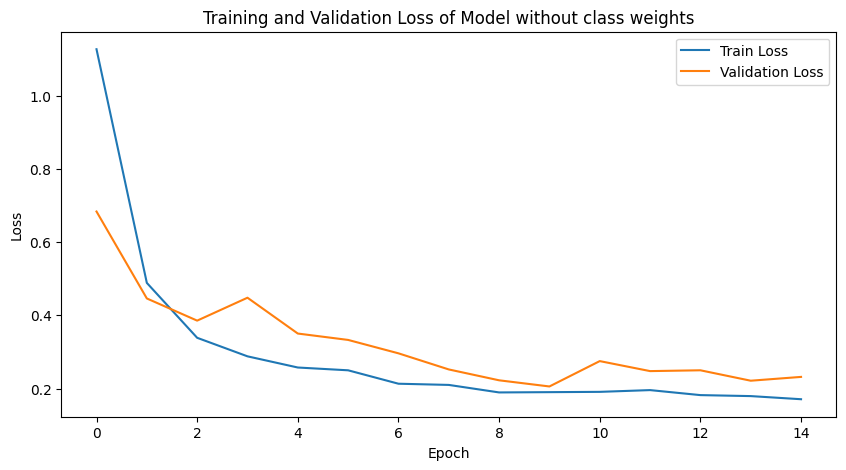

In [63]:
# training the model | best-val-loss loss-function version 0 -> w/o class weights
bvl_lfn_0 = training_loop(model, train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, optimizer, args.criterion, args.num_epochs, "Model without class weights", unique_labels, args.min_delta, args.patience)

Based on f1-score, the minor class were ignored totally with all metrics absolute 0. No, because the model focused only on major or middle classes.

In [64]:
# compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2, 3]), y=prep.y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
args.criterion = CrossEntropyLoss(weight=class_weights_tensor.to(device))

The training partition, as it is primary on training the model.

In [65]:
# redefine model
model = ShallowNN(args.input_dim, args.hidden_dims[0], args.output_dim, activation=True).to(device)
optimizer = optim.AdamW(model.parameters(), lr=args.lr)

Epoch 20/100, Train Loss: 0.2367, Val Loss: 0.3141
Early stopping at epoch 22 (best val loss: 0.259304)
The function took 4.8776 seconds to execute.


Class Report Model with class weights:
              precision    recall  f1-score   support

      Benign       0.98      0.90      0.94      3378
 Brute Force       0.72      0.95      0.82       285
    DoS Hulk       0.94      0.91      0.93       774
    PortScan       0.21      0.98      0.34        57

    accuracy                           0.91      4494
   macro avg       0.71      0.94      0.76      4494
weighted avg       0.95      0.91      0.92      4494



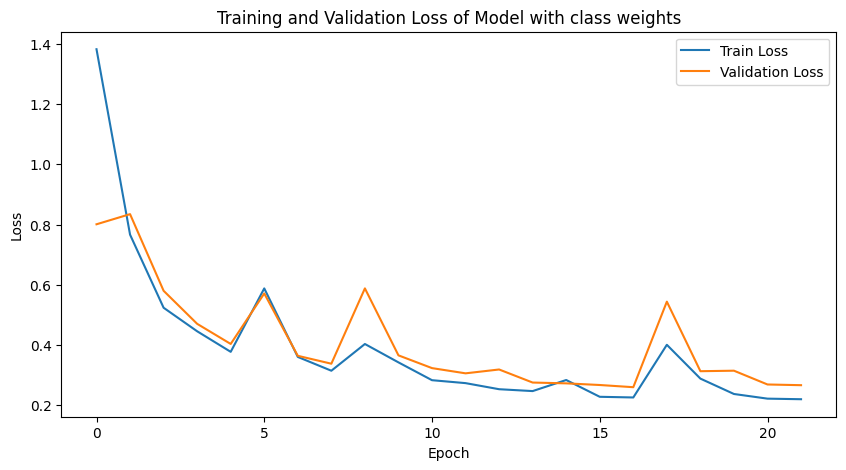

In [66]:
# training the model | best-val-loss loss-function version 1 -> with class weights
bvl_lfn_1 = training_loop(model, train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, optimizer, args.criterion, args.num_epochs, "Model with class weights", unique_labels, args.min_delta, args.patience)

Using class weights changes the model from majority-focused to minority-aware.
Without class weights, PortScan is not recognized at all (F1 = 0.00, recall = 0.00), while overall accuracy is higher (0.94) and weighted-F1 is 0.93.
With class weights, PortScan recall improves strongly (0.98) and PortScan F1 increases to 0.34; Brute Force recall also improves (0.88 -> 0.95), while DoS Hulk remains strong and Benign recall decreases (0.97 -> 0.90).
Overall, accuracy decreases (0.94 -> 0.91) and weighted-F1 slightly decreases (0.93 -> 0.92), but macro-F1 improves (0.68 -> 0.76).
This indicates better class balance and fairness across classes, at the cost of lower global accuracy.

## 3. Deep Neural Network

### 3.1 Deep Learning Model

In [67]:
# selected architectures with different number of neurons per each layer
hid_dims_set = ((8, 8, 8), (8, 16, 32), (8, 8, 8, 8), (32, 16, 16, 8), (8, 8, 8, 8, 8), (8, 16, 32, 16 ,8))

In [68]:
# hyperparameters per ech architecture
args_set = [
    Arguments(
        lr=0.0005,
        batch_size=64,
        num_epochs=50,
        criterion=CrossEntropyLoss(),
        input_dim=prep.get_input_dim(),
        hidden_dims=ns,
        output_dim=len(unique_labels),
        min_delta=5e-4,
        patience=8
    ) for ns in hid_dims_set]

In [69]:
# define models per each architecture |
models: list[DeepFFNN] = [DeepFFNN(args.input_dim, args.hidden_dims, args.output_dim).to(device) for args in args_set]
optimizers = [optim.AdamW(m.parameters(), lr=args.lr) for m, args in zip(models, args_set)]
bvl_hs = list()

Epoch 20/50, Train Loss: 0.2048, Val Loss: 0.2260
Epoch 40/50, Train Loss: 0.1368, Val Loss: 0.1540
The function took 15.8361 seconds to execute.


Class Report DeepFFNN Model with (8, 8, 8) neurons combination:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97      3378
 Brute Force       0.91      0.89      0.90       285
    DoS Hulk       0.96      0.92      0.94       774
    PortScan       0.00      0.00      0.00        57

    accuracy                           0.96      4494
   macro avg       0.71      0.70      0.70      4494
weighted avg       0.94      0.96      0.95      4494



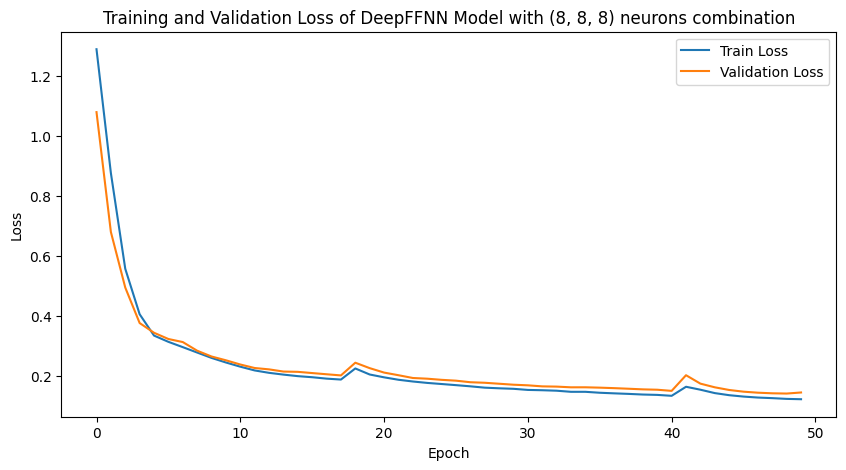

Epoch 20/50, Train Loss: 0.1654, Val Loss: 0.1898
Epoch 40/50, Train Loss: 0.1142, Val Loss: 0.1284
The function took 15.1102 seconds to execute.


Class Report DeepFFNN Model with (8, 16, 32) neurons combination:
              precision    recall  f1-score   support

      Benign       0.97      0.98      0.97      3378
 Brute Force       0.82      0.89      0.85       285
    DoS Hulk       0.97      0.92      0.94       774
    PortScan       0.92      0.58      0.71        57

    accuracy                           0.96      4494
   macro avg       0.92      0.84      0.87      4494
weighted avg       0.96      0.96      0.96      4494



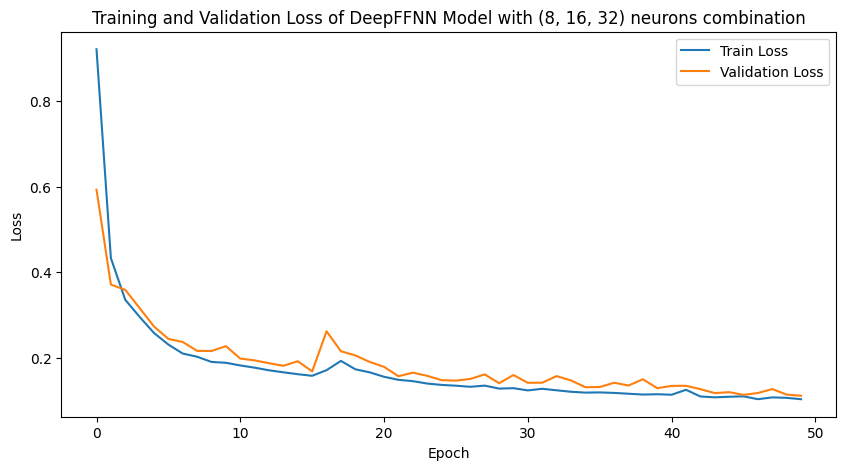

Epoch 20/50, Train Loss: 0.1572, Val Loss: 0.1677
Early stopping at epoch 39 (best val loss: 0.136485)
The function took 12.9391 seconds to execute.


Class Report DeepFFNN Model with (8, 8, 8, 8) neurons combination:
              precision    recall  f1-score   support

      Benign       0.96      0.98      0.97      3378
 Brute Force       0.81      0.88      0.85       285
    DoS Hulk       0.97      0.91      0.94       774
    PortScan       0.71      0.09      0.16        57

    accuracy                           0.95      4494
   macro avg       0.86      0.72      0.73      4494
weighted avg       0.95      0.95      0.94      4494



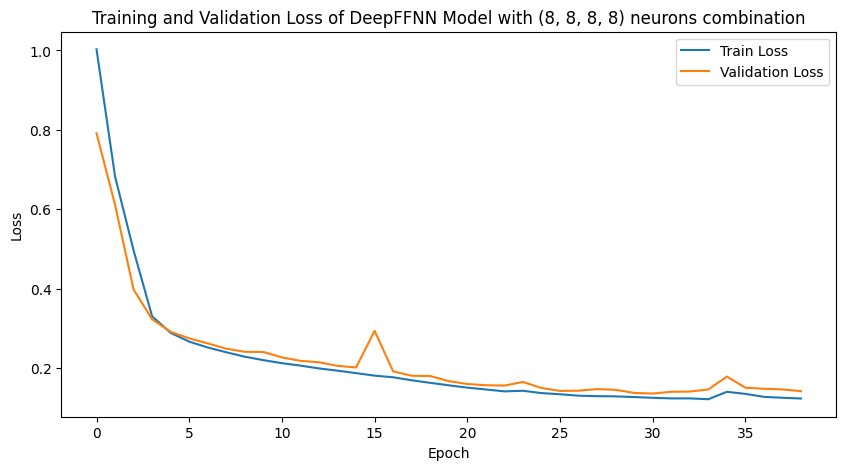

Epoch 20/50, Train Loss: 0.1442, Val Loss: 0.1592
Early stopping at epoch 38 (best val loss: 0.139083)
The function took 12.2681 seconds to execute.


Class Report DeepFFNN Model with (32, 16, 16, 8) neurons combination:
              precision    recall  f1-score   support

      Benign       0.96      0.97      0.96      3378
 Brute Force       0.81      0.89      0.85       285
    DoS Hulk       0.96      0.86      0.91       774
    PortScan       0.49      0.51      0.50        57

    accuracy                           0.94      4494
   macro avg       0.81      0.81      0.80      4494
weighted avg       0.94      0.94      0.94      4494



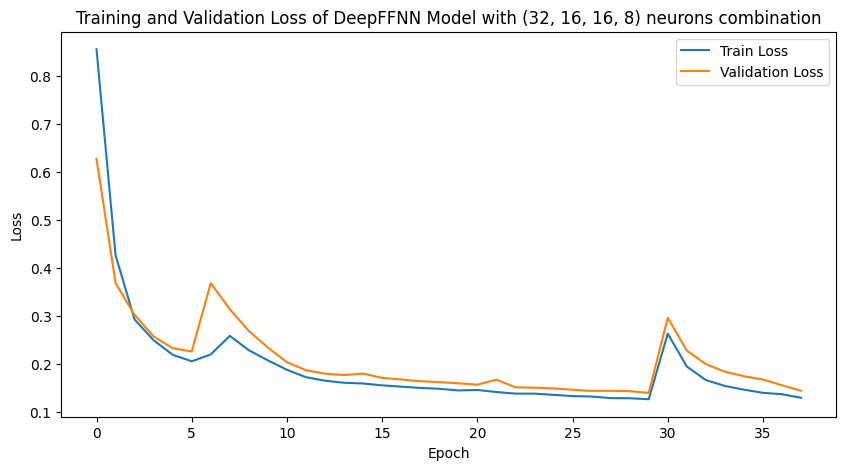

Epoch 20/50, Train Loss: 0.2865, Val Loss: 0.2862
Epoch 40/50, Train Loss: 0.2075, Val Loss: 0.2129
The function took 17.9873 seconds to execute.


Class Report DeepFFNN Model with (8, 8, 8, 8, 8) neurons combination:
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.98      3378
 Brute Force       0.56      0.89      0.68       285
    DoS Hulk       0.96      0.86      0.91       774
    PortScan       0.75      0.05      0.10        57

    accuracy                           0.94      4494
   macro avg       0.81      0.69      0.67      4494
weighted avg       0.95      0.94      0.94      4494



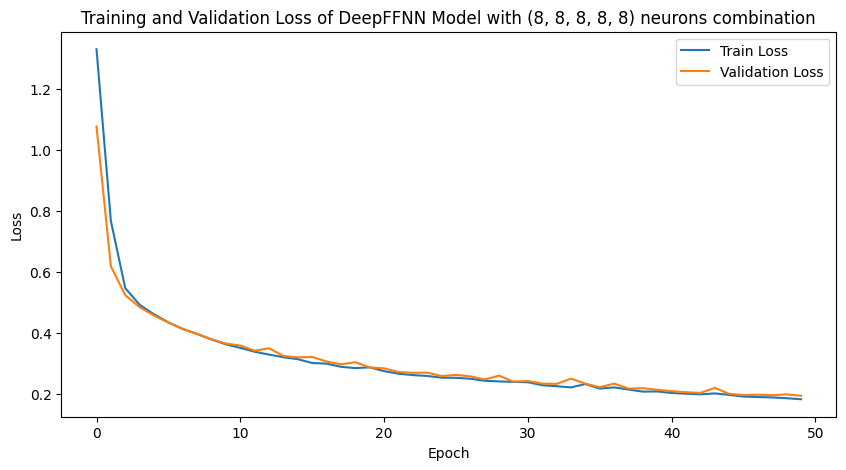

Epoch 20/50, Train Loss: 0.1671, Val Loss: 0.1920
Epoch 40/50, Train Loss: 0.1376, Val Loss: 0.1552
The function took 17.6436 seconds to execute.


Class Report DeepFFNN Model with (8, 16, 32, 16, 8) neurons combination:
              precision    recall  f1-score   support

      Benign       0.94      0.99      0.97      3378
 Brute Force       0.93      0.88      0.90       285
    DoS Hulk       0.98      0.86      0.92       774
    PortScan       0.00      0.00      0.00        57

    accuracy                           0.95      4494
   macro avg       0.71      0.68      0.70      4494
weighted avg       0.94      0.95      0.94      4494



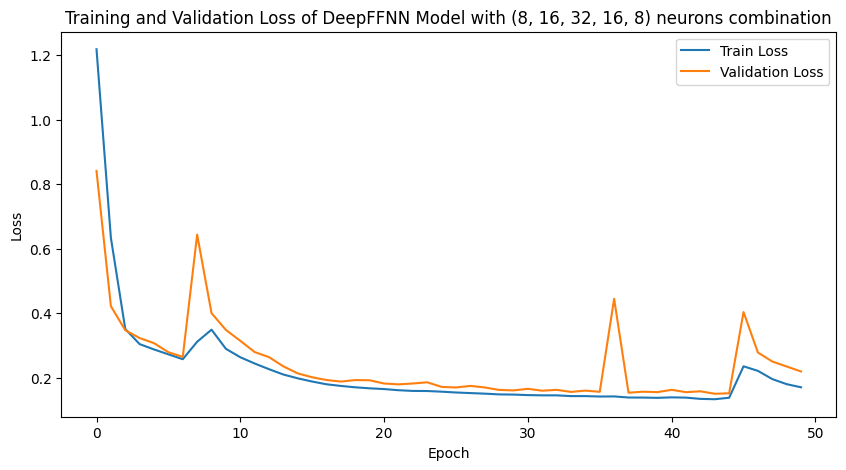

In [70]:
# training deep models
for i in range(len(hid_dims_set)):bvl_hs.append(training_loop(models[i], train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, optimizers[i], args_set[i].criterion, args_set[i].num_epochs, f'DeepFFNN Model with ({", ".join(map(str, hid_dims_set[i]))}) neurons combination', unique_labels, args_set[i].min_delta, args_set[i].patience))

The loss curves decrease and then plateau, so the models converge; the main difference is convergence speed and final validation loss across architectures.

In [71]:
# extracting best model
best_idx = bvl_hs.index(min(bvl_hs))
args = args_set[best_idx]
best_hidden_dims = hid_dims_set[best_idx]

We collected the best validation loss from each model training, and we chose the model with the best minimum validation loss across all other models.

The function took 0.0366 seconds to execute.


Class Report DeepFFNN Model with (8, 16, 32) neurons combination:
              precision    recall  f1-score   support

      Benign       0.97      0.98      0.97      3378
 Brute Force       0.79      0.90      0.84       286
    DoS Hulk       0.98      0.92      0.95       773
    PortScan       1.00      0.60      0.75        57

    accuracy                           0.96      4494
   macro avg       0.93      0.85      0.88      4494
weighted avg       0.96      0.96      0.96      4494



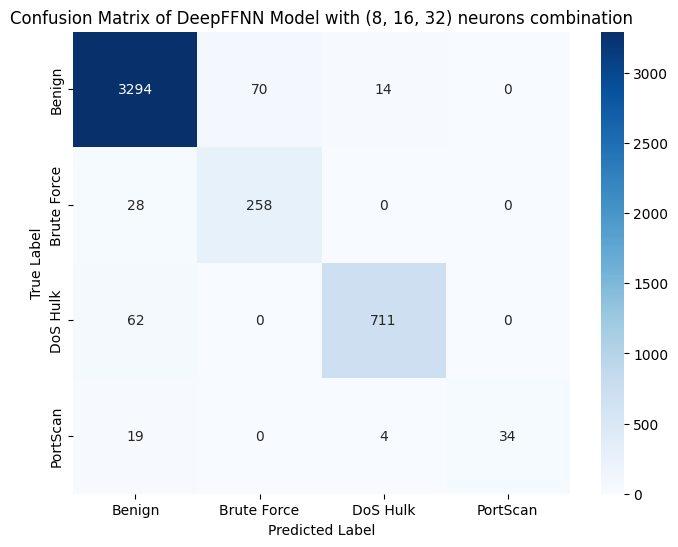

In [72]:
# test the best model
acc_best_hs = testing_model(models[best_idx], test_loader, device, f'DeepFFNN Model with ({", ".join(map(str, hid_dims_set[best_idx]))}) neurons combination', unique_labels)

### 3.2 The impact of Batch Size

Epoch 20/50, Train Loss: 0.0935, Val Loss: 0.1387
Epoch 40/50, Train Loss: 0.0766, Val Loss: 0.0956
Early stopping at epoch 41 (best val loss: 0.082879)
The function took 151.5870 seconds to execute.


Class Report DeepFFNN Model with batch size of 4:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      3378
 Brute Force       0.94      0.95      0.94       285
    DoS Hulk       0.95      0.96      0.96       774
    PortScan       0.87      0.68      0.76        57

    accuracy                           0.97      4494
   macro avg       0.93      0.89      0.91      4494
weighted avg       0.97      0.97      0.97      4494



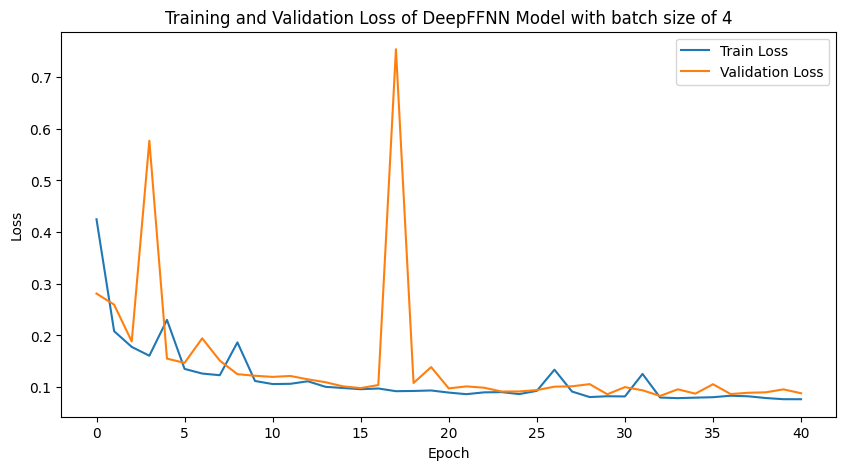

Epoch 20/50, Train Loss: 0.1402, Val Loss: 0.1592
Early stopping at epoch 33 (best val loss: 0.135808)
The function took 9.6830 seconds to execute.


Class Report DeepFFNN Model with batch size of 64:
              precision    recall  f1-score   support

      Benign       0.96      0.98      0.97      3378
 Brute Force       0.80      0.89      0.84       285
    DoS Hulk       0.98      0.90      0.94       774
    PortScan       0.88      0.39      0.54        57

    accuracy                           0.95      4494
   macro avg       0.90      0.79      0.82      4494
weighted avg       0.95      0.95      0.95      4494



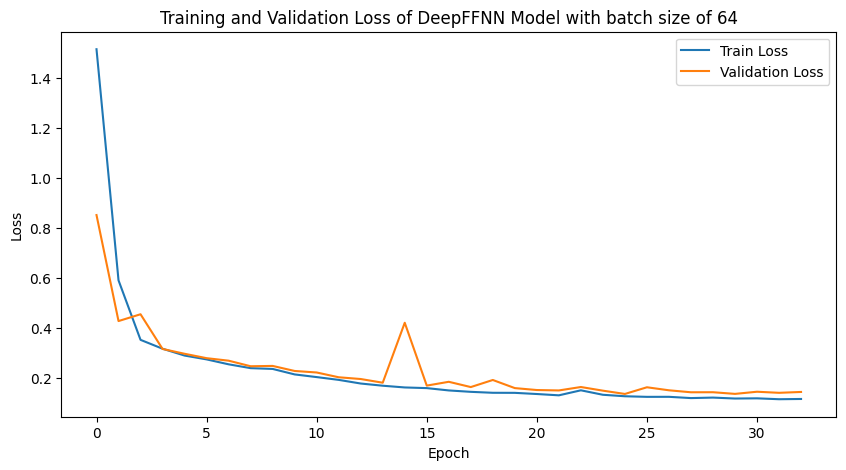

Epoch 20/50, Train Loss: 0.2445, Val Loss: 0.2708
Epoch 40/50, Train Loss: 0.1673, Val Loss: 0.1764
The function took 6.5953 seconds to execute.


Class Report DeepFFNN Model with batch size of 256:
              precision    recall  f1-score   support

      Benign       0.94      0.98      0.96      3378
 Brute Force       0.80      0.89      0.84       285
    DoS Hulk       0.98      0.85      0.91       774
    PortScan       0.75      0.11      0.18        57

    accuracy                           0.94      4494
   macro avg       0.87      0.71      0.72      4494
weighted avg       0.94      0.94      0.93      4494



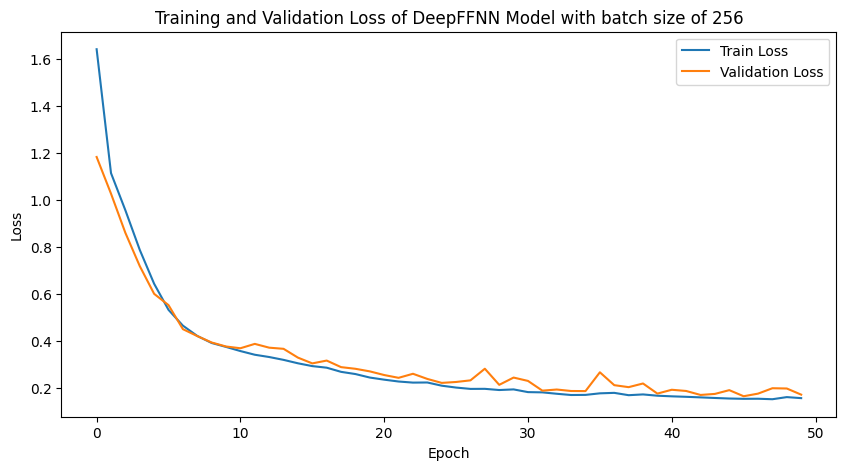

Epoch 20/50, Train Loss: 0.4314, Val Loss: 0.4478
Epoch 40/50, Train Loss: 0.2635, Val Loss: 0.2847
The function took 4.9785 seconds to execute.


Class Report DeepFFNN Model with batch size of 1024:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95      3378
 Brute Force       0.89      0.56      0.69       285
    DoS Hulk       0.99      0.85      0.92       774
    PortScan       0.00      0.00      0.00        57

    accuracy                           0.93      4494
   macro avg       0.70      0.60      0.64      4494
weighted avg       0.92      0.93      0.92      4494



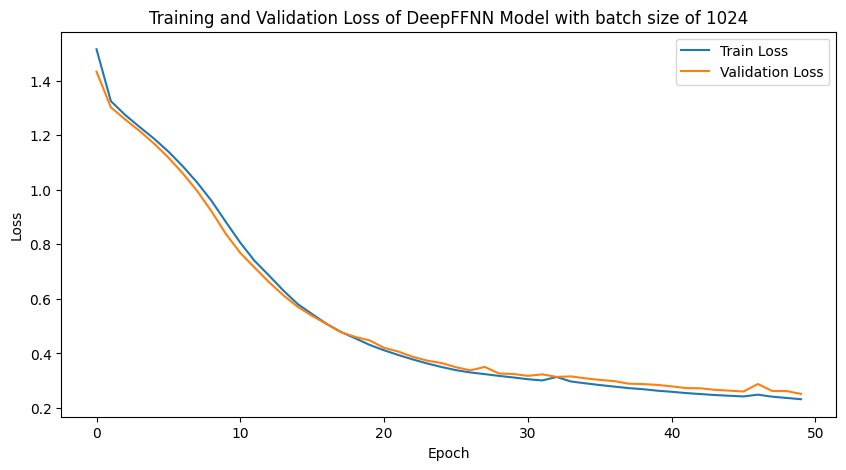

In [73]:
# define batches list
batch_sizes = (4, 64, 256, 1024)

# define loaders [train_loader, val_loader]
data_loaders = [prep.convert_to_loader(bs, test=False) for bs in batch_sizes]

# define models
models: list[DeepFFNN] = [DeepFFNN(args.input_dim, args.hidden_dims, args.output_dim).to(device) for _ in batch_sizes]
optimizers = [optim.AdamW(m.parameters(), lr=args.lr) for m in models]
bvl_bs = list()

# training deep models
for i in range(len(batch_sizes)):bvl_bs.append(training_loop(models[i], data_loaders[i]["train_loader"], data_loaders[i]["val_loader"], prep.train_dataset, prep.val_dataset, device, optimizers[i], args.criterion, args.num_epochs, f'DeepFFNN Model with batch size of {batch_sizes[i]}', unique_labels, args.min_delta, args.patience))

The small batches produce noisier gradients, that act as implicit regularization.

By increasing batch size,the time takes to training decreases, it can interpreted as time = number of samples / batch size.

In [74]:
# extracting best model
best_idx = bvl_bs.index(min(bvl_bs))
args.batch_size = batch_sizes[best_idx]
best_batch_size = batch_sizes[best_idx]

In [75]:
# create dataloader
lds = prep.convert_to_loader(args.batch_size)
train_loader = lds["train_loader"]
val_loader = lds["val_loader"]
test_loader = lds["test_loader"]

### 3.3 The impact of the Optimizer

In [76]:
# define optimizer function
def get_opt(opt, model, lr, momentum = None):
    return opt(model.parameters(), lr, momentum) if momentum is not None else opt(model.parameters(), lr)

Epoch 20/50, Train Loss: 0.2864, Val Loss: 0.3065
Epoch 40/50, Train Loss: 0.2452, Val Loss: 0.3181
Early stopping at epoch 47 (best val loss: 0.256709)
The function took 154.1750 seconds to execute.


Class Report DeepFFNN Model with Optimizer: SGD :
              precision    recall  f1-score   support

      Benign       0.92      0.98      0.95      3378
 Brute Force       0.80      0.83      0.81       285
    DoS Hulk       0.98      0.78      0.87       774
    PortScan       0.67      0.04      0.07        57

    accuracy                           0.92      4494
   macro avg       0.84      0.66      0.67      4494
weighted avg       0.92      0.92      0.92      4494



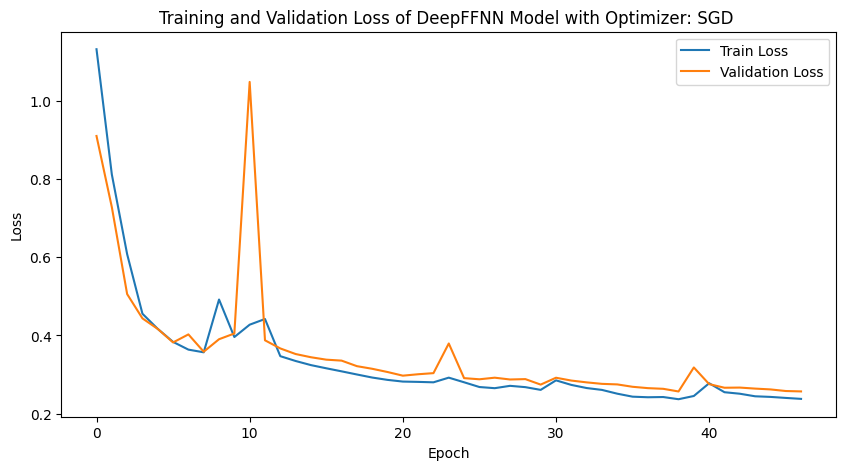

Epoch 20/50, Train Loss: 0.2707, Val Loss: 0.2966
Epoch 40/50, Train Loss: 0.2277, Val Loss: 0.2546
The function took 167.9712 seconds to execute.


Class Report DeepFFNN Model with Optimizer: SGD  with momentum 0.1:
              precision    recall  f1-score   support

      Benign       0.96      0.98      0.97      3378
 Brute Force       0.68      0.89      0.77       285
    DoS Hulk       0.98      0.86      0.91       774
    PortScan       0.00      0.00      0.00        57

    accuracy                           0.94      4494
   macro avg       0.65      0.68      0.66      4494
weighted avg       0.93      0.94      0.94      4494



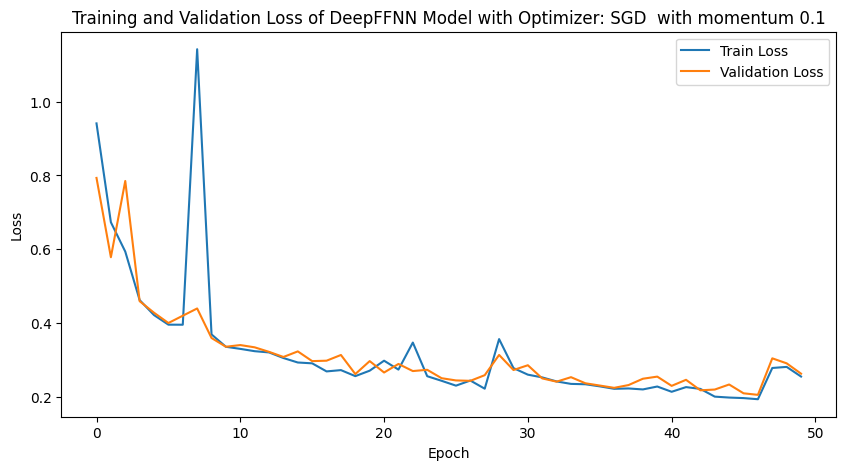

Epoch 20/50, Train Loss: 0.2404, Val Loss: 0.2527
Early stopping at epoch 35 (best val loss: 0.223486)
The function took 117.1222 seconds to execute.


Class Report DeepFFNN Model with Optimizer: SGD  with momentum 0.5:
              precision    recall  f1-score   support

      Benign       0.92      0.98      0.95      3378
 Brute Force       0.78      0.83      0.80       285
    DoS Hulk       1.00      0.77      0.87       774
    PortScan       0.88      0.12      0.22        57

    accuracy                           0.92      4494
   macro avg       0.89      0.68      0.71      4494
weighted avg       0.93      0.92      0.92      4494



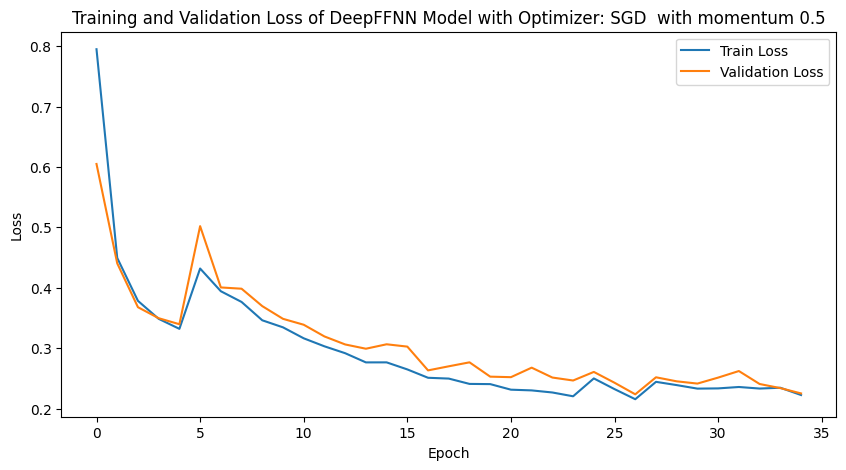

Epoch 20/50, Train Loss: 0.2197, Val Loss: 0.2477
Early stopping at epoch 26 (best val loss: 0.231708)
The function took 85.2946 seconds to execute.


Class Report DeepFFNN Model with Optimizer: SGD  with momentum 0.9:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.96      3378
 Brute Force       0.92      0.83      0.87       285
    DoS Hulk       0.99      0.77      0.87       774
    PortScan       0.00      0.00      0.00        57

    accuracy                           0.93      4494
   macro avg       0.71      0.65      0.67      4494
weighted avg       0.92      0.93      0.92      4494



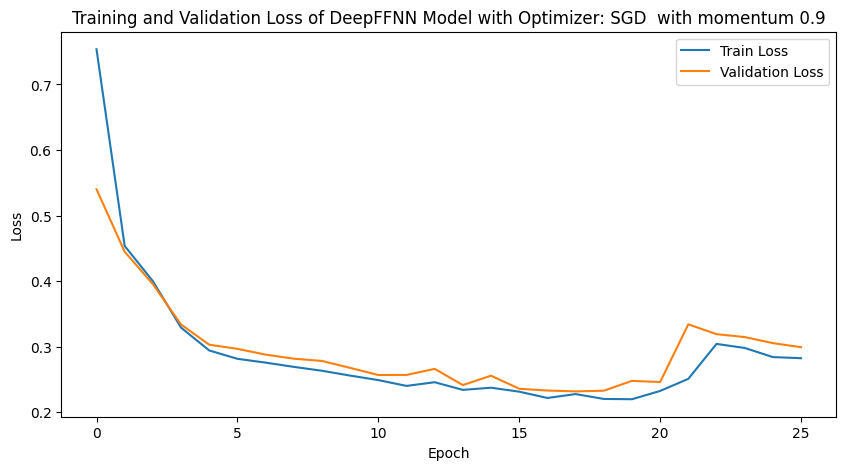

Epoch 20/50, Train Loss: 0.1664, Val Loss: 0.1095
Epoch 40/50, Train Loss: 0.0791, Val Loss: 0.0949
The function took 188.2123 seconds to execute.


Class Report DeepFFNN Model with Optimizer: AdamW :
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      3378
 Brute Force       0.92      0.95      0.93       285
    DoS Hulk       0.97      0.94      0.95       774
    PortScan       0.71      0.77      0.74        57

    accuracy                           0.97      4494
   macro avg       0.89      0.91      0.90      4494
weighted avg       0.97      0.97      0.97      4494



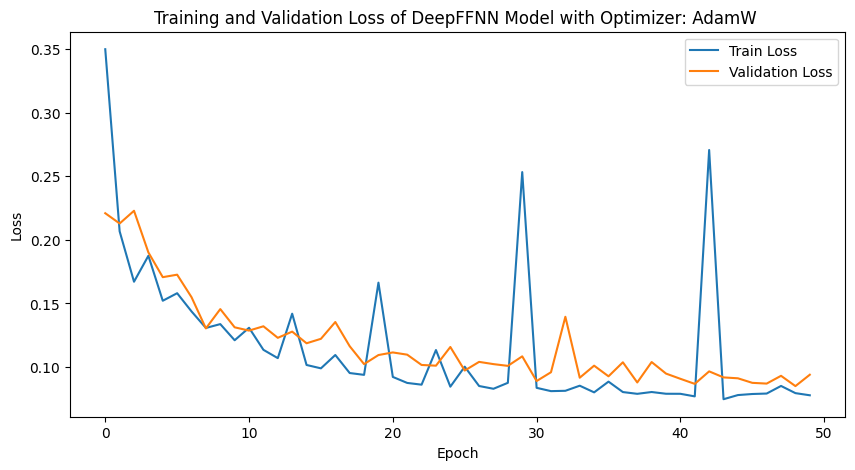

In [77]:
# define model
models: list[DeepFFNN] = [DeepFFNN(args.input_dim, args.hidden_dims, args.output_dim).to(device) for _ in range(5)]

# define optimizer list
optimizers = [{'fn': optim.SGD,'lr': args.lr, 'momentum': None}]+[{'fn': optim.SGD,'lr': args.lr,'momentum': m} for m in {0.1, 0.5, 0.9}]+[{'fn': optim.AdamW,'lr': args.lr, 'momentum': None}]
bvl_os = list()

# training deep models
for i in range(len(optimizers)):bvl_os.append(training_loop(models[i], train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, get_opt(optimizers[i]['fn'], models[i], optimizers[i]['lr'], optimizers[i]['momentum']), args.criterion, args.num_epochs, f"DeepFFNN Model with Optimizer: {optimizers[i]['fn'].__name__} {' with momentum '+str(optimizers[i]['momentum']) if optimizers[i]['momentum'] is not None else ''}", unique_labels, args.min_delta, args.patience))

SGD converges slowly and flat, the momentum can oscillate. While AdamW descends smoothly and faster.

Training time is mainly driven by the number of epochs each optimizer ran: SGD momentum=0.9 stopped earliest (epoch 26, 85s), momentum=0.5 at epoch 35 (117s), plain SGD at epoch 47 (154s), momentum=0.1 ran all 50 epochs (168s), and AdamW also ran all 50 epochs but was slowest (188s) due to extra per-step computation (two moment estimates). Despite being slowest, AdamW achieved the best performance by far (accuracy 0.97, macro-F1 0.90).

In [78]:
# extracting best model
best_idx = bvl_os.index(min(bvl_os))
best_opt = {
    'fn': optimizers[best_idx]['fn'],
    'lr': optimizers[best_idx]['lr'],
    'momentum': optimizers[best_idx]['momentum']
}

Epoch 20/50, Train Loss: 0.1535, Val Loss: 0.1667
Epoch 40/50, Train Loss: 0.1280, Val Loss: 0.1453
The function took 188.6054 seconds to execute.


Class Report DeepFFNN Model with LR=0.0001:
              precision    recall  f1-score   support

      Benign       0.95      0.98      0.96      3378
 Brute Force       0.82      0.91      0.86       285
    DoS Hulk       0.99      0.85      0.91       774
    PortScan       0.73      0.14      0.24        57

    accuracy                           0.94      4494
   macro avg       0.87      0.72      0.74      4494
weighted avg       0.94      0.94      0.94      4494



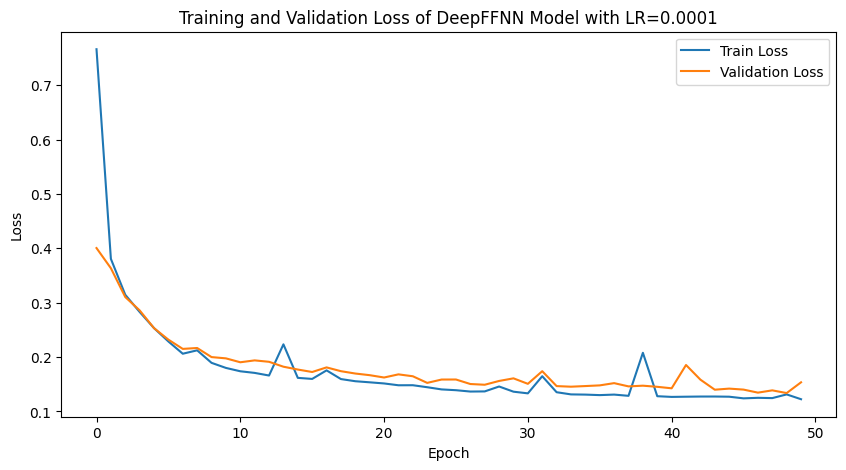

Epoch 20/50, Train Loss: 0.1031, Val Loss: 0.1344
Epoch 40/50, Train Loss: 0.1012, Val Loss: 0.1235
The function took 185.4939 seconds to execute.


Class Report DeepFFNN Model with LR=0.0005:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      3378
 Brute Force       0.94      0.94      0.94       285
    DoS Hulk       0.96      0.95      0.95       774
    PortScan       0.82      0.81      0.81        57

    accuracy                           0.97      4494
   macro avg       0.93      0.92      0.92      4494
weighted avg       0.97      0.97      0.97      4494



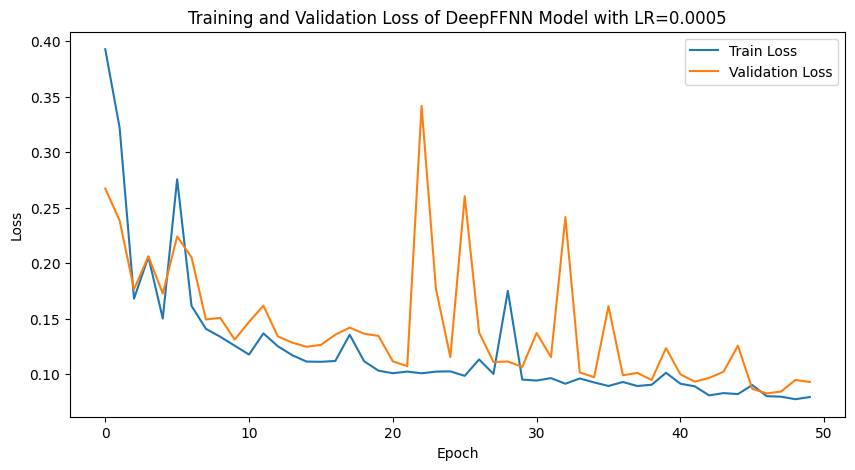

Epoch 20/50, Train Loss: 0.0908, Val Loss: 0.1275
Early stopping at epoch 34 (best val loss: 0.085689)
The function took 127.8562 seconds to execute.


Class Report DeepFFNN Model with LR=0.001:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98      3378
 Brute Force       0.93      0.95      0.94       285
    DoS Hulk       0.97      0.95      0.96       774
    PortScan       0.83      0.77      0.80        57

    accuracy                           0.98      4494
   macro avg       0.93      0.91      0.92      4494
weighted avg       0.98      0.98      0.98      4494



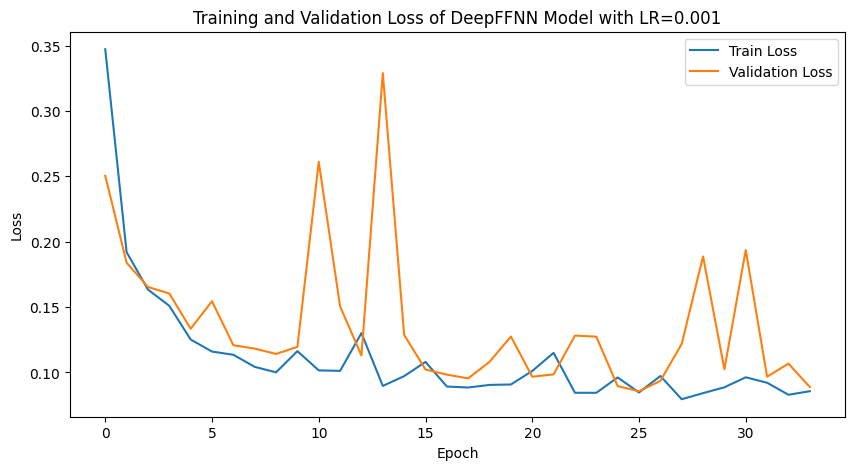

Early stopping at epoch 16 (best val loss: 0.136625)
The function took 59.8003 seconds to execute.


Class Report DeepFFNN Model with LR=0.005:
              precision    recall  f1-score   support

      Benign       0.96      0.97      0.97      3378
 Brute Force       0.80      0.94      0.86       285
    DoS Hulk       0.97      0.93      0.95       774
    PortScan       0.00      0.00      0.00        57

    accuracy                           0.95      4494
   macro avg       0.68      0.71      0.69      4494
weighted avg       0.94      0.95      0.95      4494



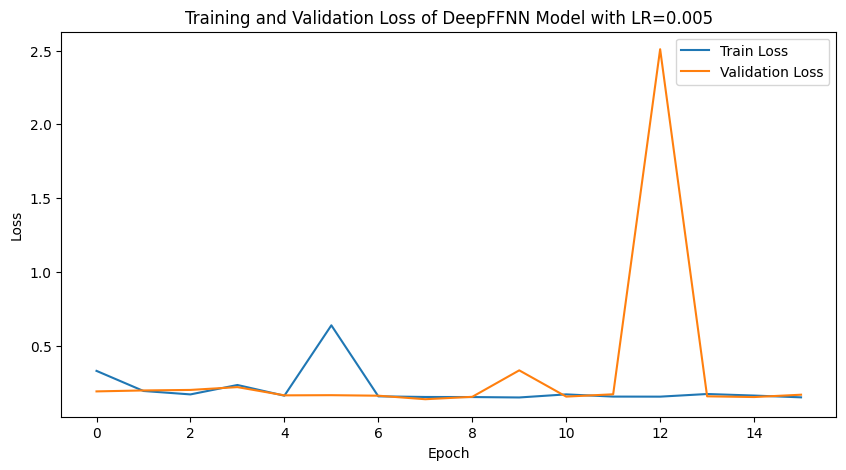

In [79]:
# define learning rates
lrs = [1e-4, 5e-4, 1e-3, 5e-3]

# define model
models: list[DeepFFNN] = [DeepFFNN(args.input_dim, args.hidden_dims, args.output_dim).to(device) for _ in range(len(lrs))]
optimizers = [get_opt(best_opt['fn'], m, lr=lr, momentum=best_opt['momentum']) for m, lr in zip(models, lrs)]
bvl_lrs = list()

# training deep models
for i in range(len(lrs)):bvl_lrs.append(training_loop(models[i], train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, optimizers[i], args.criterion, args.num_epochs, f"DeepFFNN Model with LR={lrs[i]}", unique_labels, args.min_delta, args.patience))

In [80]:
# extracting best model
best_idx = bvl_lrs.index(min(bvl_lrs))
best_lr = lrs[best_idx]

Epoch 20/50, Train Loss: 0.0877, Val Loss: 0.1085
Early stopping at epoch 37 (best val loss: 0.083443)
The function took 141.2248 seconds to execute.


Class Report The Best DeepFFNN Model:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98      3378
 Brute Force       0.94      0.93      0.93       285
    DoS Hulk       0.96      0.94      0.95       774
    PortScan       0.86      0.77      0.81        57

    accuracy                           0.97      4494
   macro avg       0.94      0.91      0.92      4494
weighted avg       0.97      0.97      0.97      4494



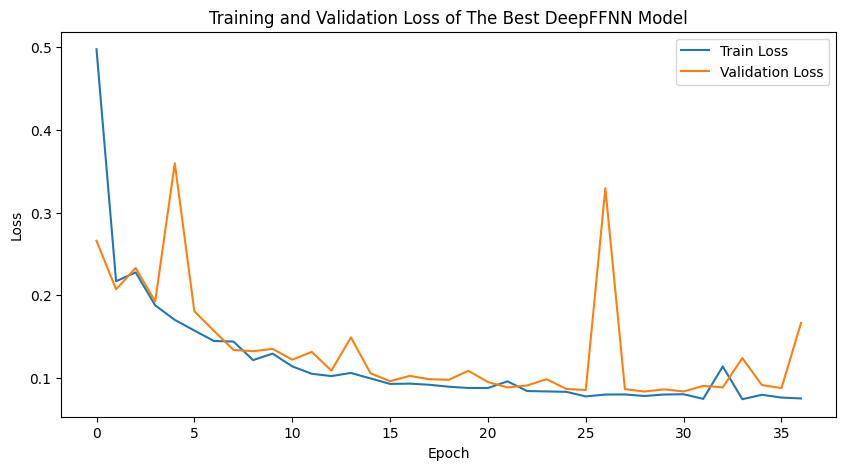

In [81]:
# best model build
args = Arguments(
        lr=best_lr,
        batch_size=best_batch_size,
        num_epochs=50,
        criterion=CrossEntropyLoss(),
        input_dim=prep.get_input_dim(),
        hidden_dims=best_hidden_dims,
        output_dim=len(unique_labels),
        min_delta=5e-4,
        patience=8
    )

model = DeepFFNN(args.input_dim, args.hidden_dims, args.output_dim).to(device)
optimizer = get_opt(best_opt['fn'], model, lr=args.lr, momentum=best_opt['momentum'])

bvl_all = training_loop(model, train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, optimizer, args.criterion, args.num_epochs, f"The Best DeepFFNN Model", unique_labels, args.min_delta, args.patience)

The function took 0.4258 seconds to execute.


Class Report DeepFFNN the best Model:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98      3378
 Brute Force       0.94      0.94      0.94       286
    DoS Hulk       0.97      0.94      0.95       773
    PortScan       0.83      0.77      0.80        57

    accuracy                           0.97      4494
   macro avg       0.93      0.91      0.92      4494
weighted avg       0.97      0.97      0.97      4494



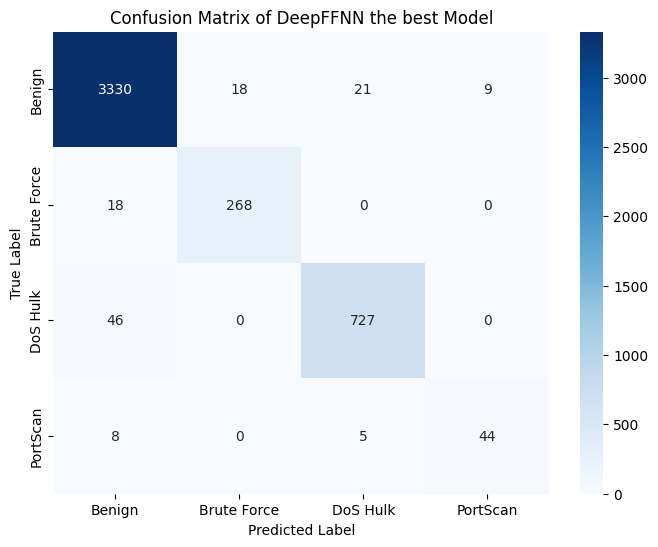

In [82]:
# test the best model
acc_best_lr = testing_model(model, test_loader, device, f'DeepFFNN the best Model', unique_labels)

## 4. Overfitting and Regularization

In [83]:
# hyperparameters
args = Arguments(
    lr=0.0005,
    batch_size=128,
    num_epochs=50,
    criterion=CrossEntropyLoss(),
    input_dim=prep.get_input_dim(),
    hidden_dims=(256, 128, 64, 32, 16),
    output_dim=len(unique_labels)
)

In [84]:
# create dataloader
lds = prep.convert_to_loader(args.batch_size)
train_loader = lds["train_loader"]
val_loader = lds["val_loader"]
test_loader = lds["test_loader"]

### 4.1 Baseline

In [85]:
# define best model
model = DeepFFNN(args.input_dim, args.hidden_dims, args.output_dim).to(device)
optimizer = optim.AdamW(model.parameters(), lr=args.lr)

Epoch 20/50, Train Loss: 0.1235, Val Loss: 0.1445
Epoch 40/50, Train Loss: 0.0873, Val Loss: 0.1031
The function took 10.3486 seconds to execute.


Class Report Deep FFNN Model baseline for Regularization:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98      3378
 Brute Force       0.94      0.94      0.94       285
    DoS Hulk       0.96      0.96      0.96       774
    PortScan       0.80      0.42      0.55        57

    accuracy                           0.97      4494
   macro avg       0.92      0.83      0.86      4494
weighted avg       0.97      0.97      0.97      4494



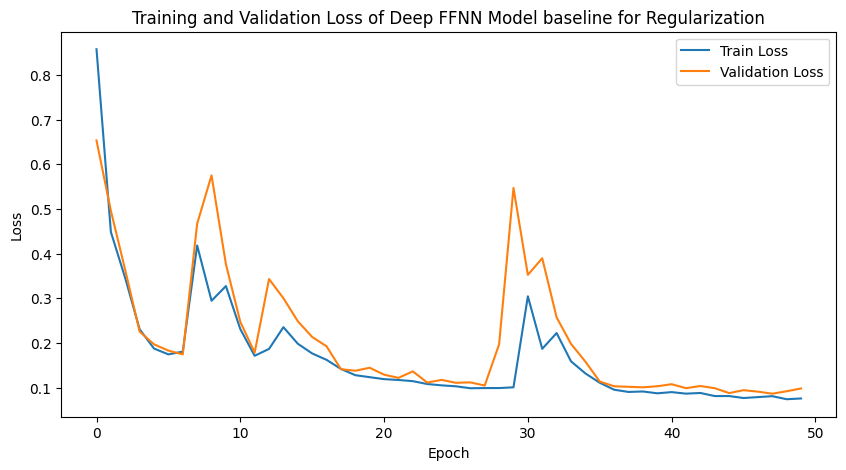

In [86]:
# training the model
bvl_baseline = training_loop(model, train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, optimizer, args.criterion, args.num_epochs, "Deep FFNN Model baseline for Regularization", unique_labels)

The function took 0.0304 seconds to execute.


Class Report DeepFFNN Model baseline for Regularization:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      3378
 Brute Force       0.93      0.95      0.94       286
    DoS Hulk       0.95      0.96      0.96       773
    PortScan       0.91      0.54      0.68        57

    accuracy                           0.97      4494
   macro avg       0.94      0.86      0.89      4494
weighted avg       0.97      0.97      0.97      4494



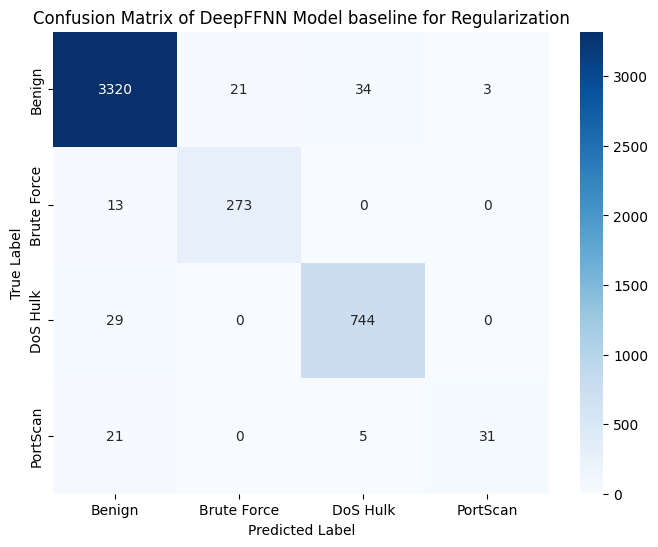

In [87]:
acc_baseline = testing_model(model, test_loader, device, f'DeepFFNN Model baseline for Regularization', unique_labels)

The losses decrease together and the gap stays stable (both train and val move in the same direction), so the model is **not overfitting**. The mild gap (~0.087 train vs ~0.103 val) remains constant rather than growing, which is the key sign — overfitting would show val loss diverging upward while train loss keeps decreasing.

### 4.2 Weight decay added

In [88]:
weight_decays = (0, 1e-4, 1e-3)

In [89]:
# define models
models = [DeepFFNN(args.input_dim, args.hidden_dims, args.output_dim).to(device) for _ in range(len(weight_decays))]
optimizers = [optim.AdamW(m.parameters(), lr=args.lr, weight_decay=wd) for wd, m in zip(weight_decays, models)]
bvl_wds = list()

Epoch 20/50, Train Loss: 0.2330, Val Loss: 0.2894
Epoch 40/50, Train Loss: 0.0841, Val Loss: 0.0963
The function took 11.0430 seconds to execute.


Class Report Deep FFNN Model with weight decay=0:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98      3378
 Brute Force       0.92      0.95      0.94       285
    DoS Hulk       0.98      0.91      0.94       774
    PortScan       0.84      0.63      0.72        57

    accuracy                           0.97      4494
   macro avg       0.93      0.87      0.89      4494
weighted avg       0.97      0.97      0.97      4494



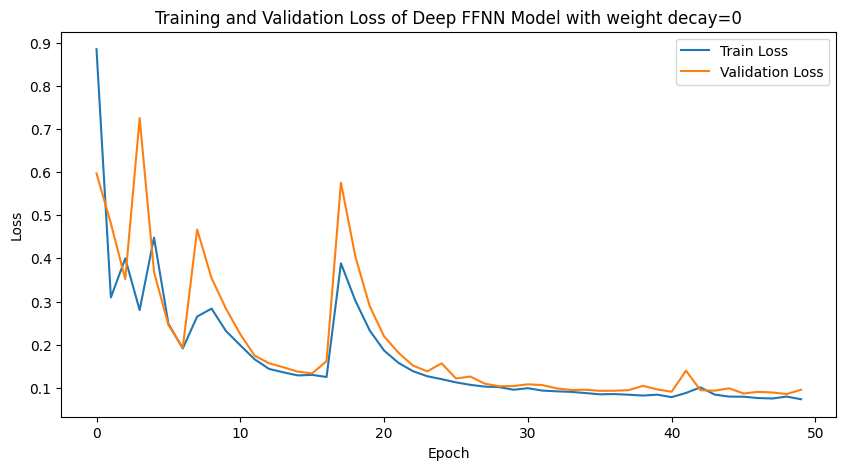

Epoch 20/50, Train Loss: 0.3402, Val Loss: 0.3824
Epoch 40/50, Train Loss: 0.0843, Val Loss: 0.1019
The function took 11.0330 seconds to execute.


Class Report Deep FFNN Model with weight decay=0.0001:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98      3378
 Brute Force       0.93      0.94      0.94       285
    DoS Hulk       0.96      0.96      0.96       774
    PortScan       0.85      0.30      0.44        57

    accuracy                           0.97      4494
   macro avg       0.93      0.80      0.83      4494
weighted avg       0.97      0.97      0.97      4494



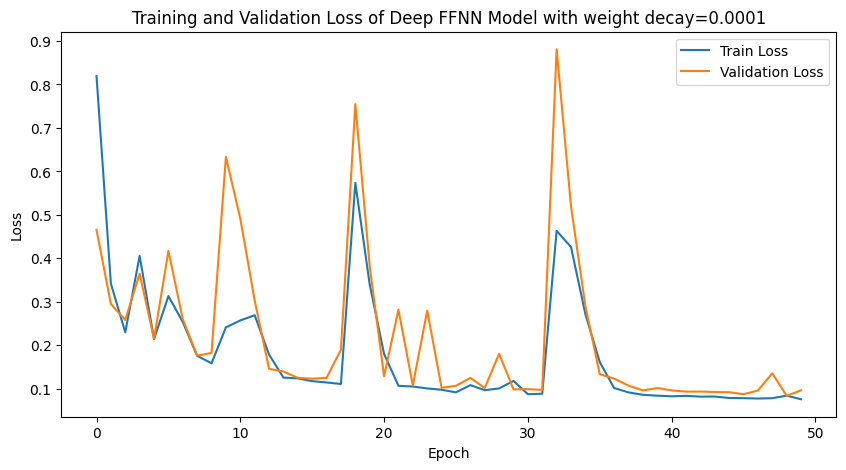

Epoch 20/50, Train Loss: 0.1149, Val Loss: 0.1249
Epoch 40/50, Train Loss: 0.1104, Val Loss: 0.1160
The function took 10.8406 seconds to execute.


Class Report Deep FFNN Model with weight decay=0.001:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      3378
 Brute Force       0.94      0.95      0.94       285
    DoS Hulk       0.96      0.95      0.95       774
    PortScan       0.72      0.77      0.75        57

    accuracy                           0.97      4494
   macro avg       0.90      0.91      0.91      4494
weighted avg       0.97      0.97      0.97      4494



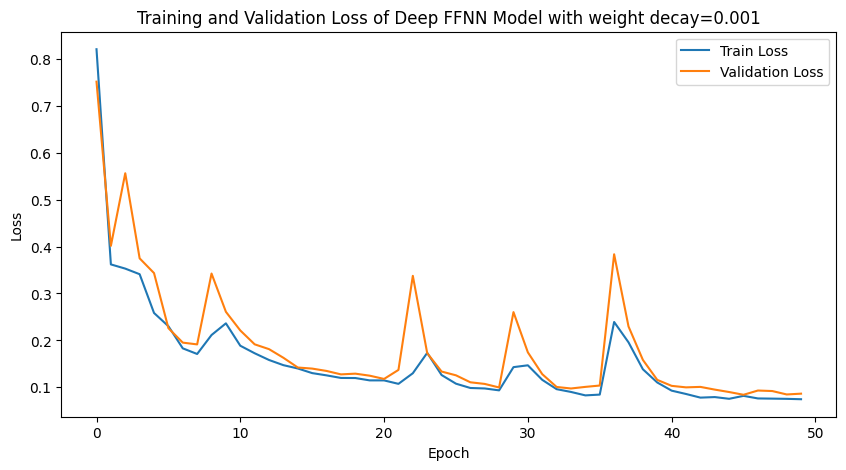

In [90]:
# training the models
for i in range(len(weight_decays)): bvl_wds.append(training_loop(models[i], train_loader, val_loader, prep.train_dataset, prep.val_dataset, device, optimizers[i], args.criterion, args.num_epochs, f"Deep FFNN Model with weight decay={weight_decays[i]}", unique_labels))

In [91]:
# extracting best model
best_idx = bvl_wds.index(min(bvl_wds))
best_weight_decay = weight_decays[best_idx]

The function took 0.0298 seconds to execute.


Class Report DeepFFNN Model with Regularization:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      3378
 Brute Force       0.94      0.95      0.95       286
    DoS Hulk       0.96      0.95      0.96       773
    PortScan       0.83      0.77      0.80        57

    accuracy                           0.97      4494
   macro avg       0.93      0.92      0.92      4494
weighted avg       0.97      0.97      0.97      4494



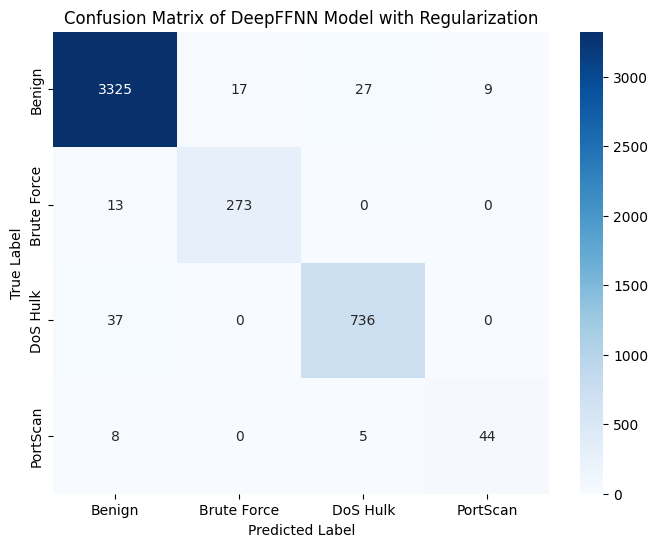

In [92]:
acc_wd = testing_model(models[best_idx], test_loader, device, "DeepFFNN Model with Regularization", unique_labels)

Only weight decay regularization was tested (values 0, 1e-4, 1e-3), with minimal impact on performance — all settings achieved ~0.97 accuracy and ~0.92 macro-F1 on test. Dropout and batch normalization were not applied, as the baseline already generalized well without them.